# Black-Litterman Q 정의 방법 7가지 비교 연구

## 프로젝트 개요
변동성 예측을 통해 Black-Litterman 모델의 Q(뷰 벡터)를 다양한 방법으로 정의하고 포트폴리오 성능을 비교합니다.

| 단계 | 방법 | 설명 |
|------|------|------|
| 1단계 | Idzorek | 베이스라인: 확신도 기반 표준 방법 |
| 2단계 | 변동성 레짐/스프레드/모멘텀 | 실현 변동성 기반 3가지 방법 |
| 3단계 | GARCH | 조건부 변동성 예측 |
| 4단계 | Regime-Switching | HMM 기반 국면 전환 |
| 5단계 | Implied Volatility | 내재 변동성 반영 |

**종목 구성**: S&P500 상위 50 / 100 / 500개  
**분석 기간**: 최대 20년 (2004-2024)

---
# 0. 환경 설정 및 공통 유틸리티

In [181]:
# ── 라이브러리 임포트 ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import linalg, optimize
from scipy.stats import norm
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
import yfinance as yf
from arch import arch_model
from hmmlearn import hmm
from tqdm.notebook import tqdm
import datetime
import os

# ── 시각화 설정 ────────────────────────────────────────────────────────────────
import matplotlib.font_manager as fm
_kor_fonts = ['Apple SD Gothic Neo', 'AppleGothic', 'Nanum Gothic']
for _f in _kor_fonts:
    if any(_f in fp for fp in fm.findSystemFonts()):
        plt.rcParams['font.family'] = _f
        break

plt.rcParams.update({
    'figure.figsize'  : (14, 6),
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'font.size'       : 11,
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'axes.unicode_minus': False,
})
sns.set_palette('tab10')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print('✅ 라이브러리 로드 완료')

✅ 라이브러리 로드 완료


In [182]:
# ── 전역 파라미터 설정 ─────────────────────────────────────────────────────────

# 기간 설정
START_DATE  = '2004-01-01'
END_DATE    = '2025-12-31'

# 종목 수 설정 (실험할 유니버스)
UNIVERSE_SIZES = [50, 100, 500]   # 순차적으로 실험
UNIVERSE_SIZE  = 50               # 기본값 (변경하여 실험)

# 리밸런싱
MAX_UNIVERSE_SIZE = 100  # 리밸런싱당 최대 종목 수 (속도/품질 균형)
REBAL_FREQ   = 'M'    # 월별 리밸런싱
ROLL_WINDOW  = 252*5  # 1년 롤링 윈도우 (거래일)
RV_SHORT     = 21     # 단기 실현변동성 윈도우 (1개월)
RV_LONG      = 63     # 장기 실현변동성 윈도우 (3개월)

# Black-Litterman 파라미터
TAU          = 0.05   # 사전 분포 불확실성 스케일
DELTA        = 2.5    # 위험 회피 계수
RF_ANNUAL    = 0.02   # 무위험 수익률 (연간)

# 거래 비용
TRANS_COST   = 0.001  # 편도 0.1%

print(f'📅 분석 기간  : {START_DATE} ~ {END_DATE}')
print(f'📊 유니버스   : {UNIVERSE_SIZE}개 종목')
print(f'⚖️  리밸런싱   : 월별')
print(f'🔢 tau        : {TAU}, delta: {DELTA}')

📅 분석 기간  : 2004-01-01 ~ 2025-12-31
📊 유니버스   : 50개 종목
⚖️  리밸런싱   : 월별
🔢 tau        : 0.05, delta: 2.5


In [183]:
# ── 사전 구축 데이터 로드 (생존편향 제거) ─────────────────────────────────────
import pickle
from pathlib import Path

DATA_DIR = Path('./data')

# 1) 가격 데이터 (역대 S&P 500 구성 종목 전부, 2004~2026)
with open(DATA_DIR / 'prices_raw.pkl', 'rb') as f:
    _prices_raw = pickle.load(f)

prices_all = _prices_raw['Close'].copy()
prices_all = prices_all.loc[START_DATE:END_DATE]

# 2) 월별 S&P 500 멤버십 딕셔너리 {month_end: frozenset(tickers)}
with open(DATA_DIR / 'sp500_membership.pkl', 'rb') as f:
    sp500_membership = pickle.load(f)

membership_dates = sorted(sp500_membership.keys())
print(f'✅ 가격 데이터: {prices_all.shape[0]}일 × {prices_all.shape[1]}종목')
print(f'   기간: {prices_all.index[0].date()} ~ {prices_all.index[-1].date()}')
print(f'✅ Membership 데이터: {len(sp500_membership)}개월')
print(f'   범위: {min(membership_dates).date()} ~ {max(membership_dates).date()}')
print()
print('📌 생존편향 제거 방식:')
print('   → 매 리밸런싱 시점에 해당 날짜의 실제 S&P 500 구성 종목만 사용')
print('   → 상장폐지/편출 종목도 편입 기간 동안은 포트폴리오에 포함')


✅ 가격 데이터: 5535일 × 835종목
   기간: 2004-01-02 ~ 2025-12-31
✅ Membership 데이터: 267개월
   범위: 2004-01-31 ~ 2026-03-31

📌 생존편향 제거 방식:
   → 매 리밸런싱 시점에 해당 날짜의 실제 S&P 500 구성 종목만 사용
   → 상장폐지/편출 종목도 편입 기간 동안은 포트폴리오에 포함


In [184]:
# ── SPY 다운로드 + 멤버십 유틸리티 ──────────────────────────────────────────

spy = yf.download('SPY', start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)['Close'].squeeze()


def get_members_at(date: pd.Timestamp,
                   prices: pd.DataFrame,
                   membership: dict,
                   min_obs: int = ROLL_WINDOW // 2) -> list:
    """
    특정 날짜의 실제 S&P 500 구성 종목 반환 (생존편향 제거).
    membership에서 date 이하 가장 가까운 월말 데이터를 사용하여
    미래 정보(look-ahead bias) 없이 당시 구성 종목만 선택.
    """
    valid_dates = [d for d in membership if d <= date]
    if not valid_dates:
        return []
    ref_date = max(valid_dates)
    members  = membership[ref_date]

    price_slice = prices.loc[:date]
    return [
        t for t in members
        if t in prices.columns
        and price_slice[t].notna().sum() >= min_obs
    ]


def get_top_members(date, prices, membership, n, min_obs=ROLL_WINDOW // 2):
    """현재 멤버 중 데이터 완전성 기준 상위 N개 선택"""
    members = get_members_at(date, prices, membership, min_obs)
    if not members:
        return []
    completeness = prices.loc[:date, members].notna().sum()
    return completeness.nlargest(min(n, len(members))).index.tolist()


def get_members_capped(date, prices, membership,
                       max_n=None, min_obs=ROLL_WINDOW // 2):
    """
    해당 날짜 S&P 500 멤버 반환 (MAX_UNIVERSE_SIZE 상한 적용).
    max_n=None이면 MAX_UNIVERSE_SIZE 전역 파라미터 사용.
    """
    cap = max_n if max_n is not None else MAX_UNIVERSE_SIZE
    return get_top_members(date, prices, membership, n=cap, min_obs=min_obs)


print('✅ 유틸리티 함수 정의 완료')
t1 = get_members_at(pd.Timestamp('2010-01-31'), prices_all, sp500_membership)
t2 = get_members_at(pd.Timestamp('2020-01-31'), prices_all, sp500_membership)
print(f'   검증 - 2010-01-31 가용 멤버: {len(t1)}개')
print(f'   검증 - 2020-01-31 가용 멤버: {len(t2)}개')


✅ 유틸리티 함수 정의 완료
   검증 - 2010-01-31 가용 멤버: 352개
   검증 - 2020-01-31 가용 멤버: 456개


In [185]:
# ── 공통 계산 함수 ─────────────────────────────────────────────────────────────

# 수익률 계산 — 역대 S&P 500 전체 종목 포함 (생존편향 없음)
mkt_returns  = spy.pct_change().dropna()
returns      = prices_all.pct_change().reindex(mkt_returns.index)  # 전체 유니버스
returns      = returns.clip(-0.5, 0.5)  # 데이터 오류(극단값) 제거: ±50% 일간 수익률 상한


def realized_volatility(ret_series, window=21, annualize=True):
    """롤링 실현 변동성 계산"""
    rv = ret_series.rolling(window).std()
    return rv * np.sqrt(252) if annualize else rv


def ledoit_wolf_cov(ret_df):
    """Ledoit-Wolf 수축 공분산 행렬"""
    lw = LedoitWolf()
    lw.fit(ret_df.values)
    return pd.DataFrame(lw.covariance_,
                        index=ret_df.columns, columns=ret_df.columns)


def market_cap_weights(price_slice):
    """시가총액 근사 비중 (마지막 가격 기준 균등 근사)"""
    n = len(price_slice.columns)
    return np.ones(n) / n   # 단순 균등 (시가총액 데이터 없을 때)


def bl_implied_returns(w_mkt, sigma, delta=DELTA):
    """Black-Litterman 균형 내재 수익률 (Pi)"""
    return delta * sigma @ w_mkt


def black_litterman(
    pi, sigma, P, Q, omega,
    tau=TAU, delta=DELTA
):
    """
    Black-Litterman 사후 기대수익률 계산

    Parameters
    ----------
    pi    : (N,) 균형 내재 수익률
    sigma : (N,N) 공분산 행렬
    P     : (K,N) 뷰 행렬
    Q     : (K,) 뷰 벡터
    omega : (K,K) 뷰 불확실성 행렬
    tau   : 스케일 파라미터
    delta : 위험 회피 계수

    Returns
    -------
    mu_bl : (N,) 사후 기대수익률
    sigma_bl : (N,N) 사후 공분산
    """
    tau_sigma = tau * sigma
    # 사후 공분산 (역행렬 수식)
    inv_tau_sigma = np.linalg.inv(tau_sigma)
    inv_omega     = np.linalg.inv(omega)
    M_inv = inv_tau_sigma + P.T @ inv_omega @ P
    M     = np.linalg.inv(M_inv)
    # 사후 기대수익률
    mu_bl = M @ (inv_tau_sigma @ pi + P.T @ inv_omega @ Q)
    # 사후 공분산
    sigma_bl = sigma + M
    return mu_bl, sigma_bl


def mean_variance_weights(mu, sigma, delta=DELTA, long_only=True):
    """
    MV 최적화 (분석적 해 or 제약 최적화)
    Returns: 정규화된 비중 벡터
    """
    n = len(mu)
    try:
        if long_only:
            from scipy.optimize import minimize
            def neg_sharpe(w):
                port_ret = w @ mu
                port_var = w @ sigma @ w
                return -(port_ret / np.sqrt(port_var + 1e-8))

            constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
            bounds = [(0, 0.20)] * n  # 최대 20% 상한
            w0 = np.ones(n) / n
            res = optimize.minimize(
                neg_sharpe, w0,
                method='SLSQP',
                bounds=bounds,
                constraints=constraints,
                options={'ftol': 1e-9, 'maxiter': 1000}
            )
            return res.x if res.success else w0
        else:
            # 제약 없는 해석적 해
            w = np.linalg.solve(delta * sigma, mu)
            return w / w.sum()
    except Exception:
        return np.ones(n) / n


print('✅ 공통 함수 정의 완료')
print(f'   수익률 기간: {returns.index[0].date()} ~ {returns.index[-1].date()}')
print(f'   총 거래일: {len(returns)}일')

✅ 공통 함수 정의 완료
   수익률 기간: 2004-01-05 ~ 2025-12-30
   총 거래일: 5533일


In [186]:
# ── 백테스트 엔진 ──────────────────────────────────────────────────────────────

def run_backtest(
    weights_history: pd.DataFrame,
    returns: pd.DataFrame,
    trans_cost: float = TRANS_COST,
    label: str = 'Strategy'
) -> pd.Series:
    """
    포트폴리오 백테스트 (가변 유니버스 지원).
    weights_history 각 행에서 NaN이 아닌 종목만 해당 기간 보유.
    """
    port_returns = []
    prev_w       = pd.Series(dtype=float)
    rebal_dates  = weights_history.index

    for i, rebal_date in enumerate(rebal_dates):
        next_date  = rebal_dates[i + 1] if i + 1 < len(rebal_dates) else returns.index[-1]
        mask       = (returns.index >= rebal_date) & (returns.index < next_date)
        period_ret = returns[mask]
        if len(period_ret) == 0:
            continue

        # 이번 기간 보유 종목 (NaN 제외, returns에도 존재하는 것만)
        w_series = weights_history.loc[rebal_date].dropna()
        avail    = [t for t in w_series.index if t in period_ret.columns]
        if not avail:
            continue
        w = w_series[avail].values.astype(float)
        if w.sum() == 0:
            continue
        w = w / w.sum()

        # 거래비용: 이전 비중과 비교 (종목 구성 변경 포함)
        if len(prev_w) > 0:
            w_new  = pd.Series(w, index=avail)
            all_t  = w_new.index.union(prev_w.index)
            tc = (w_new.reindex(all_t, fill_value=0)
                  - prev_w.reindex(all_t, fill_value=0)).abs().sum() * trans_cost
        else:
            tc = 0

        daily_ret = period_ret[avail].fillna(0) @ w
        daily_ret.iloc[0] -= tc
        port_returns.append(daily_ret)
        prev_w = pd.Series(w, index=avail)

    if not port_returns:
        return pd.Series(dtype=float, name=label)
    result = pd.concat(port_returns)
    result.name = label
    return result


def compute_metrics(ret_series: pd.Series, rf: float = RF_ANNUAL) -> dict:
    if ret_series.empty or ret_series.std() == 0:
        return {}
    ann_ret  = ret_series.mean() * 252
    ann_vol  = ret_series.std()  * np.sqrt(252)
    sharpe   = (ann_ret - rf) / ann_vol
    neg_ret  = ret_series[ret_series < 0]
    downside = neg_ret.std() * np.sqrt(252)
    sortino  = (ann_ret - rf) / (downside + 1e-8)
    cum      = (1 + ret_series).cumprod()
    mdd      = ((cum - cum.cummax()) / cum.cummax()).min()
    calmar   = ann_ret / (abs(mdd) + 1e-8)
    return {
        '연간수익률(%)': round(ann_ret * 100, 2),
        '연간변동성(%)': round(ann_vol * 100, 2),
        '샤프비율'     : round(sharpe,  3),
        '소르티노'     : round(sortino, 3),
        'MDD(%)'       : round(mdd * 100, 2),
        'Calmar'       : round(calmar,  3),
        '거래일수'     : len(ret_series),
    }


# ── 동적 동일가중 벤치마크 (생존편향 없음) ────────────────────────────────────
_ew_rebal = returns.resample('ME').last().index[ROLL_WINDOW // 21:]
_ew_rows  = []
for _date in _ew_rebal:
    _tickers = get_members_capped(_date, returns, sp500_membership)
    if _tickers:
        _n = len(_tickers)
        _ew_rows.append({'date': _date, **{t: 1 / _n for t in _tickers}})

ew_weights_hist = pd.DataFrame(_ew_rows).set_index('date')
ew_ret = run_backtest(ew_weights_hist, returns, label='동일가중')

print('✅ 백테스트 엔진 준비 완료')
bm = compute_metrics(ew_ret)
print(f'   동일가중 벤치마크: 샤프={bm.get("샤프비율","N/A")}, 연수익={bm.get("연간수익률(%)","N/A")}%')


✅ 백테스트 엔진 준비 완료
   동일가중 벤치마크: 샤프=0.766, 연수익=16.56%


In [187]:
returns.head()

Ticker,A,AA,AAL,AAP,AAPL,ABBV,ABK,ABMD,ABNB,ABS,ABT,ACAS,ACE,ACGL,ACN,ADBE,ADCT,ADI,ADM,ADP,ADS,ADSK,ADT,AEE,AEP,AES,AET,AFL,AGN,AIG,AIV,AIZ,AJG,AKAM,AKS,ALB,ALGN,ALK,ALL,ALLE,ALTR,ALXN,AMAT,AMCR,AMD,AME,AMG,AMGN,AMP,AMT,AMTM,AMZN,AN,ANDV,ANET,ANF,ANR,ANSS,AON,AOS,APA,APC,APD,APH,APO,APOL,APP,APTV,ARE,ARES,ARG,ARNC,ATI,ATO,ATVI,AV,AVB,AVGO,AVP,AVY,AWK,AXON,AXP,AYE,AYI,AZO,BA,BAC,BALL,BAX,BBBY,BBWI,BBY,BC,BCR,BDX,BEAM,BEN,BF-B,BG,BHF,BHI,BIG,BIIB,BIO,BJS,BK,BKNG,BKR,BLDR,BLK,BMC,BMS,BMY,BR,BRCM,BRK-B,BRO,BSX,BTU,BWA,BX,BXLT,BXP,C,CA,CAG,CAH,CAM,CARR,CAT,CB,CBE,CBOE,CBRE,CCE,CCI,CCL,CDNS,CDW,CE,CEG,CELG,CEPH,CERN,CF,CFC,CFG,CFN,CHD,CHK,CHRW,CHTR,CI,CIEN,CINF,CL,CLF,CLX,CMA,CMCSA,CMCSK,CME,CMG,CMI,CMS,CNC,CNP,CNX,COF,COHR,COIN,COL,COO,COP,COR,COST,COTY,COV,CPAY,CPB,CPGX,CPRI,CPRT,CPT,CPWR,CRH,CRL,CRM,CRWD,CSC,CSCO,CSGP,CSRA,CSX,CTAS,CTLT,CTRA,SPY,^IRX,CTSH,CTVA,CTX,CTXS,CVC,CVG,CVH,CVNA,CVS,CVX,CXO,CZR,D,DAL,DASH,DAY,DD,DDOG,DE,DECK,DELL,DF,DFS,DG,DGX,DHI,DHR,DIS,DISCA,DISCK,DISH,DJ,DLR,DLTR,DNB,DNR,DO,DOC,DOV,DOW,DPS,DPZ,DRE,DRI,DTE,DTV,DUK,DV,DVA,DVN,DWDP,DXC,DXCM,DYN,EA,EBAY,ECL,ED,EFX,EG,EIX,EK,EL,ELV,EMC,EME,EMN,EMR,ENDP,ENPH,EOG,EP,EPAM,EQIX,EQR,EQT,ERIE,ES,ESRX,ESS,ESV,ETFC,ETN,ETR,ETSY,EVHC,EVRG,EW,EXC,EXE,EXPD,EXPE,EXR,F,FANG,FAST,FBHS,FCX,FDC,FDO,FDS,FDX,FE,FFIV,FHN,FICO,FII,FIS,FISV,FITB,FIX,FL,FLIR,FLR,FLS,FMC,FNM,FOSL,FOX,FOXA,FRC,FRE,FRT,FRX,FSLR,FTI,FTNT,FTR,FTV,GAS,GD,GDDY,GE,GEHC,GEN,GENZ,GEV,GGP,GHC,GILD,GIS,GL,GLK,GLW,GM,GMCR,GME,GNRC,GNW,GOOGL,GPC,GPN,GPS,GR,GRMN,GS,GT,GWW,HAL,HAR,HAS,HBAN,HBI,HCA,HCBK,HD,HES,HFC,HIG,HII,HLT,HNZ,HOG,HOLX,HON,HOOD,HOT,HP,HPE,HPQ,HRB,HRL,HSIC,HSP,HST,HSY,HUBB,HUM,HWM,IBKR,IBM,ICE,IDXX,IEX,IFF,IGT,ILMN,INCY,INFO,INTC,INTU,INVH,IP,IPG,IPGP,IQV,IR,IRM,ISRG,IT,ITT,ITW,IVZ,J,JBHT,JBL,JCI,JCP,JDSU,JEF,JKHY,JNJ,JNPR,JNS,JNY,JOY,JPM,JWN,K,KBH,KDP,KEY,KEYS,KFT,KG,KHC,KIM,KKR,KLAC,KMB,KMI,KMX,KO,KR,KRFT,KSE,KSS,KSU,KVUE,L,LDOS,LEG,LEH,LEN,LH,LHX,LIFE,LII,LIN,LITE,LKQ,LLL,LLTC,LLY,LM,LMT,LNC,LNT,LO,LOW,LRCX,LSI,LULU,LUMN,LUV,LVLT,LVS,LW,LXK,LYB,LYV,M,MA,MAA,MAC,MAR,MAS,MAT,MBI,MCD,MCHP,MCK,MCO,MDLZ,MDP,MDT,MEE,MET,META,MFE,MGM,MHK,MHS,MI,MIL,MJN,MKC,MKTX,MLM,MMI,MMM,MNK,MNST,MO,MOH,MOLX,MON,MOS,MPC,MPWR,MRK,MRNA,MRO,MRSH,MS,MSCI,MSFT,MSI,MTB,MTCH,MTD,MU,MUR,MWW,MXIM,NAVI,NBL,NBR,NCLH,NCR,NDAQ,NDSN,NE,NEE,NEM,NFLX,NFX,NI,NKE,NKTR,NLSN,NOC,NOV,NOVL,NOW,NRG,NSC,NSM,NTAP,NTRS,NUE,NVDA,NVLS,NVR,NWL,NWS,NWSA,NXPI,NYT,NYX,O,ODFL,ODP,OGN,OI,OKE,OMC,OMX,ON,ORCL,ORLY,OTIS,OXY,PANW,PAYC,PAYX,PBCT,PBI,PCAR,PCG,PCL,PCP,PCS,PDCO,PEG,PENN,PEP,PETM,PFE,PFG,PG,PGN,PGR,PH,PHM,PKG,PLD,PLL,PLTR,PM,PNC,PNR,PNW,PODD,POM,POOL,PPG,PPL,PRGO,PRU,PSA,PSKY,PSX,PTC,PTV,PVH,PWR,PXD,PYPL,Q,QCOM,QEP,QRVO,R,RAI,RCL,RDC,REG,REGN,RF,RHI,RHT,RIG,RJF,RL,RMD,ROK,ROL,ROP,ROST,RRC,RRD,RSG,RSH,RTN,RTX,RVTY,RX,S,SAI,SATS,SBAC,SBL,SBNY,SBUX,SCG,SCHW,SE,SEDG,SEE,SGP,SHLD,SHW,SIAL,SIG,SII,SIVB,SJM,SLB,SLE,SLG,SLM,SLR,SMCI,SNA,SNDK,SNI,SNPS,SO,SOLS,SOLV,SPG,SPGI,SPLS,SRCL,SRE,STE,STI,STJ,STLD,STR,STT,STX,STZ,SUN,SVU,SW,SWK,SWKS,SWN,SWY,SYF,SYK,SYY,T,TAP,TDC,TDG,TDY,TE,TECH,TEG,TEL,TER,TFC,TFX,TGNA,TGT,THC,TIE,TIF,TJX,TKO,TLAB,TMO,TMUS,TPL,TPR,TRB,TRGP,TRIP,TRMB,TROW,TRV,TSCO,TSG,TSLA,TSN,TSS,TT,TTD,TTWO,TWC,TWTR,TWX,TXN,TXT,TYC,TYL,UA,UAA,UAL,UBER,UDR,UHS,ULTA,UNH,UNM,UNP,UPS,URBN,URI,USB,V,VAR,VFC,VIAB,VICI,VLO,VLTO,VMC,VNO,VNT,VRSK,VRSN,VRT,VRTX,VST,VTR,VTRS,VZ,WAB,WAT,WB,WBA,WBD,WCG,WDAY,WDC,WEC,WELL,WFC,WFM,WFR,WHR,WIN,WM,WMB,WMT,WPX,WRB,WSM,WST,WTW,WU,WY,WYN,WYNN,X,XEC,XEL,XL,XLNX,XOM,XRAY,XRX,XTO,XYL,XYZ,YHOO,YUM,ZBH,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

---
# 1단계: Idzorek 방식 (베이스라인)

## 핵심 아이디어
투자자가 **확신도(confidence, 0~100%)** 를 직접 입력하면, 이를 Ω(뷰 불확실성)로 자동 변환합니다.

$$\Omega_i = \frac{1-c_i}{c_i} \cdot \tau \cdot P_i \Sigma P_i^T$$

여기서 $c_i$는 i번째 뷰에 대한 확신도입니다.

In [188]:
# ── Idzorek 방법 구현 ──────────────────────────────────────────────────────────

class IdzorekBL:
    """
    Idzorek (2005) 방식 Black-Litterman
    
    뷰: 각 종목의 기대수익률이 CAPM 균형 수익률 대비
        과거 상대적 수익률 성과만큼 편차가 있다는 절대적 뷰를 생성
    확신도: 변동성 역수에 비례 (저변동성 = 높은 확신)
    """

    def __init__(self, tau=TAU, delta=DELTA, window=ROLL_WINDOW):
        self.tau   = tau
        self.delta = delta
        self.window = window

    def compute_confidence(self, returns_slice: pd.DataFrame) -> np.ndarray:
        """변동성 역수 기반 확신도 (0~1)"""
        vols = returns_slice.std() * np.sqrt(252)
        # 역수 정규화: 저변동 → 높은 확신
        inv_vol = 1 / (vols + 1e-8)
        confidence = inv_vol / inv_vol.sum() * len(inv_vol)  # 평균=1로 스케일
        confidence = np.clip(confidence / confidence.max(), 0.01, 0.99)
        return confidence.values

    def compute_views(self, pi: np.ndarray, returns_slice: pd.DataFrame) -> np.ndarray:
        """모멘텀 기반 절대적 뷰 Q"""
        # 최근 3개월 vs 12개월 모멘텀으로 Q 조정
        mom_12 = (1 + returns_slice.iloc[-252:]).prod() - 1
        mom_3  = (1 + returns_slice.iloc[-63:]).prod() - 1
        # 12개월 모멘텀 신호를 pi에 반영
        signal = (mom_12 - mom_12.mean()) / (mom_12.std() + 1e-8)
        Q = pi + 0.03/252 * signal.values  # pi에 작은 편차 추가
        return Q

    def idzorek_omega(self, P: np.ndarray, sigma: np.ndarray,
                      confidence: np.ndarray) -> np.ndarray:
        """Idzorek (2005) 수식으로 Omega 계산"""
        K = P.shape[0]
        omega = np.zeros((K, K))
        for i in range(K):
            p_i = P[i:i+1, :]  # (1, N)
            c_i = confidence[i]
            # Ω_i = ((1-c)/c) * τ * P_i Σ P_i^T
            variance = float(p_i @ (self.tau * sigma) @ p_i.T)
            omega[i, i] = ((1 - c_i) / (c_i + 1e-8)) * variance
        return omega

    def fit_predict(self, returns_slice: pd.DataFrame):
        """주어진 기간 수익률로 BL 비중 계산"""
        n = len(returns_slice.columns)
        sigma = ledoit_wolf_cov(returns_slice).values
        w_eq  = np.ones(n) / n
        pi    = bl_implied_returns(w_eq, sigma, self.delta)

        # P: 각 종목에 대한 절대적 뷰 (단위 행렬)
        P = np.eye(n)
        Q = self.compute_views(pi, returns_slice)
        confidence = self.compute_confidence(returns_slice)
        omega = self.idzorek_omega(P, sigma, confidence)

        mu_bl, sigma_bl = black_litterman(pi, sigma, P, Q, omega, self.tau, self.delta)
        weights = mean_variance_weights(mu_bl, sigma_bl, self.delta)
        return weights


def run_rolling_backtest(model, returns, membership=None,
                         window=ROLL_WINDOW, freq='ME', label='BL'):
    """롤링 백테스트 (membership 지정 시 생존편향 없는 동적 유니버스 사용)"""
    rebal_dates  = returns.resample(freq).last().index
    weights_list = []

    for date in tqdm(rebal_dates[window//21:], desc=f'{label} 계산중'):
        end_idx = returns.index.searchsorted(date, side='right') - 1
        if end_idx < 0:
            continue
        start_idx = max(0, end_idx - window)

        # 생존편향 제거: 해당 날짜의 실제 S&P 500 멤버만 사용
        if membership is not None:
            tickers = get_members_capped(date, returns, membership)
        else:
            tickers = returns.columns.tolist()
        if len(tickers) < 5:
            continue

        slice_ret = returns.iloc[start_idx:end_idx][tickers]
        slice_ret = slice_ret.dropna(axis=1, thresh=len(slice_ret) // 2).fillna(0)
        if len(slice_ret.columns) < 5:
            continue

        try:
            w = model.fit_predict(slice_ret)
            weights_list.append({'date': date, **dict(zip(slice_ret.columns, w))})
        except Exception:
            n = len(slice_ret.columns)
            weights_list.append({'date': date,
                                 **dict(zip(slice_ret.columns, np.ones(n) / n))})

    weights_df = pd.DataFrame(weights_list).set_index('date')
    return run_backtest(weights_df, returns, label=label)


print('✅ Idzorek 클래스 정의 완료')

✅ Idzorek 클래스 정의 완료


In [189]:
# ── Idzorek 백테스트 실행 ──────────────────────────────────────────────────────

idzorek_model = IdzorekBL(tau=TAU, delta=DELTA, window=ROLL_WINDOW)
ret_idzorek   = run_rolling_backtest(idzorek_model, returns,
                                      membership=sp500_membership,
                                      window=ROLL_WINDOW, label='Idzorek')

m = compute_metrics(ret_idzorek)
print(f'\n📊 Idzorek 성능 요약')
for k, v in m.items():
    print(f'   {k}: {v}')

Idzorek 계산중:   0%|          | 0/204 [00:00<?, ?it/s]


📊 Idzorek 성능 요약
   연간수익률(%): 16.56
   연간변동성(%): 19.0
   샤프비율: 0.766
   소르티노: 0.971
   MDD(%): -38.65
   Calmar: 0.429
   거래일수: 4255


In [190]:
ret_idzorek.head()

Date
2009-02-02   -0.007043
2009-02-03    0.016465
2009-02-04   -0.007319
2009-02-05    0.021776
2009-02-06    0.035578
Name: Idzorek, dtype: float64

---
# 2단계: 실현 변동성 기반 3가지 방법

## 2-1. 변동성 레짐 기반 Q
변동성 수준(저/중/고)을 분류하고 레짐별 기대수익률 뷰를 부여합니다.

## 2-2. 변동성 스프레드 기반 Q  
개별 종목 RV와 시장 RV의 차이를 뷰 신호로 활용합니다.

## 2-3. 변동성 모멘텀 기반 Q
변동성의 추세(단기/장기 비율)를 뷰 신호로 활용합니다.

In [191]:
# ── 2-1. 변동성 레짐 기반 Q ────────────────────────────────────────────────────

class VolRegimeBL:
    """
    변동성 레짐 기반 Q
    
    저변동 레짐 → 상향 뷰 (Q = pi + alpha)
    고변동 레짐 → 하향 뷰 (Q = pi - alpha)
    중립 레짐  → Q = pi
    """

    def __init__(self, tau=TAU, delta=DELTA,
                 window=ROLL_WINDOW, rv_window=21,
                 low_q=0.33, high_q=0.67, alpha_scale=0.02):
        self.tau         = tau
        self.delta       = delta
        self.window      = window
        self.rv_window   = rv_window
        self.low_q       = low_q
        self.high_q      = high_q
        self.alpha_scale = alpha_scale

    def classify_regime(self, rv_series: pd.Series) -> pd.Series:
        """변동성 레짐 분류: 0=저, 1=중, 2=고"""
        low_th  = rv_series.quantile(self.low_q)
        high_th = rv_series.quantile(self.high_q)
        regime = pd.cut(rv_series,
                        bins=[-np.inf, low_th, high_th, np.inf],
                        labels=[0, 1, 2])
        return regime.astype(int)

    def fit_predict(self, returns_slice: pd.DataFrame):
        n     = len(returns_slice.columns)
        sigma = ledoit_wolf_cov(returns_slice).values
        w_eq  = np.ones(n) / n
        pi    = bl_implied_returns(w_eq, sigma, self.delta)

        # 각 종목의 현재 변동성 레짐 파악
        rv_all    = realized_volatility(returns_slice, window=self.rv_window)
        rv_latest = rv_all.iloc[-1]  # 최신 RV

        Q = pi.copy()
        for i, ticker in enumerate(returns_slice.columns):
            rv_hist   = rv_all[ticker].dropna()
            regime    = self.classify_regime(rv_hist)
            cur_regime = regime.iloc[-1]

            # 레짐별 조정
            if cur_regime == 0:   # 저변동 → 낙관
                alpha = self.alpha_scale * rv_hist.mean()
                Q[i]  = pi[i] + alpha
            elif cur_regime == 2: # 고변동 → 비관
                alpha = self.alpha_scale * rv_hist.mean()
                Q[i]  = pi[i] - alpha
            # 중립: Q = pi (변경 없음)

        # Omega: 레짐 불확실성에 비례
        P     = np.eye(n)
        omega_diag = []
        for i, ticker in enumerate(returns_slice.columns):
            rv_hist   = rv_all[ticker].dropna()
            regime    = self.classify_regime(rv_hist)
            cur_regime = regime.iloc[-1]
            # 고변동 레짐일수록 불확실성 높음
            uncertainty_multiplier = {0: 0.5, 1: 1.0, 2: 2.0}[cur_regime]
            omega_diag.append(self.tau * sigma[i, i] * uncertainty_multiplier)

        omega = np.diag(omega_diag)
        mu_bl, sigma_bl = black_litterman(pi, sigma, P, Q, omega, self.tau, self.delta)
        return mean_variance_weights(mu_bl, sigma_bl, self.delta)


print('✅ 변동성 레짐 BL 클래스 정의 완료')

✅ 변동성 레짐 BL 클래스 정의 완료


In [192]:
# ── 2-2. 변동성 스프레드 기반 Q ────────────────────────────────────────────────

class VolSpreadBL:
    """
    변동성 스프레드 기반 Q
    
    spread_i = RV_i - RV_market
    Q_i = pi_i - lambda * spread_i (정규화)
    스프레드 클수록 → 고유 리스크 높음 → 하향 뷰
    """

    def __init__(self, tau=TAU, delta=DELTA, window=ROLL_WINDOW,
                 rv_window=21, lam=0.5):
        self.tau       = tau
        self.delta     = delta
        self.window    = window
        self.rv_window = rv_window
        self.lam       = lam  # 스프레드 민감도

    def fit_predict(self, returns_slice: pd.DataFrame,
                    mkt_ret: pd.Series = None):
        n     = len(returns_slice.columns)
        sigma = ledoit_wolf_cov(returns_slice).values
        w_eq  = np.ones(n) / n
        pi    = bl_implied_returns(w_eq, sigma, self.delta)

        # 실현 변동성
        rv_stocks = (returns_slice.std() * np.sqrt(252)).values

        if mkt_ret is not None:
            mkt_aligned = mkt_ret.reindex(returns_slice.index).dropna()
            rv_market   = mkt_aligned.std() * np.sqrt(252)
        else:
            rv_market = np.mean(rv_stocks)  # 종목 평균 대체

        # 스프레드 계산 및 정규화
        spread = rv_stocks - rv_market
        spread_norm = (spread - spread.mean()) / (spread.std() + 1e-8)

        # Q 조정
        Q = pi - self.lam * spread_norm * pi.std()

        # Omega: 스프레드 크기에 비례한 불확실성
        P = np.eye(n)
        spread_uncertainty = np.abs(spread_norm)
        spread_uncertainty = spread_uncertainty / spread_uncertainty.max()
        omega = np.diag(self.tau * np.diag(sigma) *
                        (0.5 + spread_uncertainty))

        mu_bl, sigma_bl = black_litterman(pi, sigma, P, Q, omega, self.tau, self.delta)
        return mean_variance_weights(mu_bl, sigma_bl, self.delta)


print('✅ 변동성 스프레드 BL 클래스 정의 완료')

✅ 변동성 스프레드 BL 클래스 정의 완료


In [193]:
# ── 2-3. 변동성 모멘텀 기반 Q ──────────────────────────────────────────────────

class VolMomentumBL:
    """
    변동성 모멘텀 기반 Q
    
    vol_momentum = RV(단기) / RV(장기) - 1
    양수(변동성 증가 추세) → 하향 뷰
    음수(변동성 감소 추세) → 상향 뷰
    """

    def __init__(self, tau=TAU, delta=DELTA, window=ROLL_WINDOW,
                 short_w=RV_SHORT, long_w=RV_LONG, gamma=0.5):
        self.tau     = tau
        self.delta   = delta
        self.window  = window
        self.short_w = short_w
        self.long_w  = long_w
        self.gamma   = gamma  # 모멘텀 신호 민감도

    def fit_predict(self, returns_slice: pd.DataFrame):
        n     = len(returns_slice.columns)
        sigma = ledoit_wolf_cov(returns_slice).values
        w_eq  = np.ones(n) / n
        pi    = bl_implied_returns(w_eq, sigma, self.delta)

        # 단기/장기 실현 변동성
        if len(returns_slice) < self.long_w + 5:
            return np.ones(n) / n

        rv_short = (returns_slice.iloc[-self.short_w:].std() * np.sqrt(252)).values
        rv_long  = (returns_slice.iloc[-self.long_w:].std()  * np.sqrt(252)).values

        # 변동성 모멘텀 (정규화)
        vol_mom = (rv_short / (rv_long + 1e-8)) - 1
        vol_mom_norm = (vol_mom - vol_mom.mean()) / (vol_mom.std() + 1e-8)

        # Q 조정: 모멘텀 양수 → 뷰 하향
        Q = pi - self.gamma * vol_mom_norm * pi.std()

        # Omega: 모멘텀 절대값에 비례한 불확실성
        P = np.eye(n)
        uncertainty = np.abs(vol_mom_norm)
        uncertainty = uncertainty / (uncertainty.max() + 1e-8)
        omega = np.diag(self.tau * np.diag(sigma) * (0.5 + uncertainty))

        mu_bl, sigma_bl = black_litterman(pi, sigma, P, Q, omega, self.tau, self.delta)
        return mean_variance_weights(mu_bl, sigma_bl, self.delta)


print('✅ 변동성 모멘텀 BL 클래스 정의 완료')

✅ 변동성 모멘텀 BL 클래스 정의 완료


In [194]:
# ── 2단계 백테스트 실행 ────────────────────────────────────────────────────────

# 공통 롤링 백테스트 함수 (시장 수익률 포함 버전)
def run_rolling_bt_with_mkt(model, returns, mkt_returns=None,
                             membership=None,
                             window=ROLL_WINDOW, freq='ME', label='BL'):
    rebal_dates  = returns.resample(freq).last().index
    weights_list = []

    for date in tqdm(rebal_dates[window//21:], desc=f'{label} 계산중'):
        end_idx   = returns.index.searchsorted(date, side='right') - 1
        if end_idx < 0:
            continue
        start_idx = max(0, end_idx - window)

        if membership is not None:
            tickers = get_members_capped(date, returns, membership)
        else:
            tickers = returns.columns.tolist()
        if len(tickers) < 5:
            continue

        slice_ret = returns.iloc[start_idx:end_idx][tickers]
        slice_ret = slice_ret.dropna(axis=1, thresh=len(slice_ret) // 2).fillna(0)
        if len(slice_ret.columns) < 5:
            continue

        try:
            if mkt_returns is not None and hasattr(model, 'mkt_ret'):
                mkt_slice = mkt_returns.iloc[start_idx:end_idx]
                w = model.fit_predict(slice_ret, mkt_slice)
            elif mkt_returns is not None:
                # VolSpreadBL은 mkt_ret 인자 있음
                try:
                    mkt_slice = mkt_returns.iloc[start_idx:end_idx]
                    w = model.fit_predict(slice_ret, mkt_slice)
                except TypeError:
                    w = model.fit_predict(slice_ret)
            else:
                w = model.fit_predict(slice_ret)

            weights_list.append({'date': date,
                                  **dict(zip(slice_ret.columns, w))})
        except Exception as e:
            n = len(slice_ret.columns)
            weights_list.append({'date': date,
                                  **dict(zip(slice_ret.columns, np.ones(n)/n))})

    weights_df = pd.DataFrame(weights_list).set_index('date')
    return run_backtest(weights_df, returns, label=label)


regime_model   = VolRegimeBL()
spread_model   = VolSpreadBL()
momentum_model = VolMomentumBL()

ret_regime   = run_rolling_bt_with_mkt(regime_model,   returns, membership=sp500_membership, label='변동성레짐')
ret_spread   = run_rolling_bt_with_mkt(spread_model,   returns, mkt_returns, membership=sp500_membership, label='변동성스프레드')
ret_momentum = run_rolling_bt_with_mkt(momentum_model, returns, membership=sp500_membership, label='변동성모멘텀')

print('\n📊 2단계 성능 요약')
for name, ret in [('변동성레짐', ret_regime),
                   ('변동성스프레드', ret_spread),
                   ('변동성모멘텀', ret_momentum)]:
    m = compute_metrics(ret)
    print(f'  {name}: 샤프={m.get("샤프비율","N/A")}, 연수익={m.get("연간수익률(%)","N/A")}%')


변동성레짐 계산중:   0%|          | 0/204 [00:00<?, ?it/s]

변동성스프레드 계산중:   0%|          | 0/204 [00:00<?, ?it/s]

변동성모멘텀 계산중:   0%|          | 0/204 [00:00<?, ?it/s]


📊 2단계 성능 요약
  변동성레짐: 샤프=0.489, 연수익=14.82%
  변동성스프레드: 샤프=0.798, 연수익=13.91%
  변동성모멘텀: 샤프=0.689, 연수익=14.04%


In [195]:
print(ret_regime.head())
print(ret_spread.head())
print(ret_momentum.head())

Date
2009-02-02   -0.039052
2009-02-03   -0.063917
2009-02-04   -0.058552
2009-02-05    0.107652
2009-02-06    0.126193
Name: 변동성레짐, dtype: float64
Date
2009-02-02   -0.004981
2009-02-03    0.020814
2009-02-04   -0.003476
2009-02-05    0.009046
2009-02-06    0.013531
Name: 변동성스프레드, dtype: float64
Date
2009-02-02    0.000551
2009-02-03    0.021191
2009-02-04   -0.000939
2009-02-05    0.011365
2009-02-06    0.016844
Name: 변동성모멘텀, dtype: float64


---
# 3단계: GARCH 기반 조건부 변동성

## 핵심 아이디어
GARCH(1,1) 또는 GJR-GARCH로 미래 변동성을 직접 예측하여 Q에 반영합니다.

$$\sigma^2_{t+1} = \omega + \alpha \epsilon^2_t + \beta \sigma^2_t$$

$$Q_i = \pi_i \times \frac{\sigma^{hist}_i}{\sigma^{GARCH}_{i,t+1}}$$

In [196]:
# ── GARCH 기반 BL ──────────────────────────────────────────────────────────────

class GARCHBL:
    """
    GARCH(1,1) / GJR-GARCH 기반 조건부 변동성 예측으로 Q 결정
    
    예측 변동성 > 역사적 변동성 → 뷰 하향 (리스크 상승)
    예측 변동성 < 역사적 변동성 → 뷰 상향 (리스크 감소)
    """

    def __init__(self, tau=TAU, delta=DELTA, window=ROLL_WINDOW,
                 model_type='garch', n_forecast=21):
        self.tau        = tau
        self.delta      = delta
        self.window     = window
        self.model_type = model_type   # 'garch' or 'gjr'
        self.n_forecast = n_forecast   # 예측 기간 (일)

    def fit_garch(self, ret_series: pd.Series) -> float:
        """단일 시계열 GARCH 적합 및 변동성 예측"""
        try:
            ret_pct = ret_series * 100  # % 단위로 변환 (수치 안정성)
            if self.model_type == 'gjr':
                am = arch_model(ret_pct, vol='Garch', p=1, o=1, q=1,
                                dist='normal', rescale=False)
            else:
                am = arch_model(ret_pct, vol='Garch', p=1, q=1,
                                dist='normal', rescale=False)

            res = am.fit(disp='off', show_warning=False,
                         options={'maxiter': 200})
            # 1일 앞 예측
            forecast = res.forecast(horizon=self.n_forecast)
            # n_forecast일 평균 분산의 연환산 변동성
            mean_var  = forecast.variance.iloc[-1].mean()
            garch_vol = np.sqrt(mean_var / 100**2 * 252)  # 연간화
            return garch_vol
        except Exception:
            # 추정 실패 시 역사적 변동성 반환
            return ret_series.std() * np.sqrt(252)

    def fit_predict(self, returns_slice: pd.DataFrame):
        n     = len(returns_slice.columns)
        sigma = ledoit_wolf_cov(returns_slice).values
        w_eq  = np.ones(n) / n
        pi    = bl_implied_returns(w_eq, sigma, self.delta)

        # 각 종목 GARCH 예측 변동성
        hist_vols  = (returns_slice.std() * np.sqrt(252)).values
        garch_vols = np.array([
            self.fit_garch(returns_slice[col])
            for col in returns_slice.columns
        ])

        # Q = pi * (hist_vol / garch_vol)
        vol_ratio = hist_vols / (garch_vols + 1e-8)
        # 극단값 클리핑
        vol_ratio = np.clip(vol_ratio, 0.5, 2.0)
        Q = pi * vol_ratio

        # Omega: GARCH 예측 변동성에 비례한 불확실성
        P = np.eye(n)
        garch_normalized = garch_vols / (hist_vols + 1e-8)
        omega = np.diag(self.tau * np.diag(sigma) *
                        np.clip(garch_normalized, 0.5, 3.0))

        mu_bl, sigma_bl = black_litterman(pi, sigma, P, Q, omega, self.tau, self.delta)
        return mean_variance_weights(mu_bl, sigma_bl, self.delta)


print('✅ GARCH BL 클래스 정의 완료')
print(f'   모델 타입: GARCH(1,1) 및 GJR-GARCH(1,1,1)')

✅ GARCH BL 클래스 정의 완료
   모델 타입: GARCH(1,1) 및 GJR-GARCH(1,1,1)


In [197]:
# ── GARCH 백테스트 실행 ────────────────────────────────────────────────────────
# ⚠️ 종목 수가 많을수록 시간이 상당히 걸립니다 (50개 기준 ~20분)

garch_model   = GARCHBL(model_type='garch')
gjr_model     = GARCHBL(model_type='gjr')

ret_garch = run_rolling_bt_with_mkt(garch_model, returns, membership=sp500_membership, label='GARCH')
ret_gjr   = run_rolling_bt_with_mkt(gjr_model,   returns, membership=sp500_membership, label='GJR-GARCH')

print('\n📊 GARCH 성능 요약')
for name, ret in [('GARCH(1,1)', ret_garch), ('GJR-GARCH', ret_gjr)]:
    m = compute_metrics(ret)
    print(f'  {name}: 샤프={m.get("샤프비율","N/A")}, 연수익={m.get("연간수익률(%)","N/A")}%')

GARCH 계산중:   0%|          | 0/204 [00:00<?, ?it/s]

GJR-GARCH 계산중:   0%|          | 0/204 [00:00<?, ?it/s]


📊 GARCH 성능 요약
  GARCH(1,1): 샤프=0.601, 연수익=12.84%
  GJR-GARCH: 샤프=0.537, 연수익=11.7%


In [198]:
print(ret_garch.head())
print(ret_gjr.head())

Date
2009-02-02    0.005912
2009-02-03    0.016384
2009-02-04   -0.004350
2009-02-05    0.013811
2009-02-06    0.016532
Name: GARCH, dtype: float64
Date
2009-02-02    0.006607
2009-02-03    0.015607
2009-02-04    0.000610
2009-02-05    0.012868
2009-02-06    0.012529
Name: GJR-GARCH, dtype: float64


---
# 4단계: Regime-Switching (HMM 기반 국면 전환)

## 핵심 아이디어
Hidden Markov Model로 시장 국면을 확률적으로 추정하고, 국면별 기대수익률의 가중평균을 Q로 사용합니다.

$$Q_t = P(Bull|data_t) \times \mu_{bull} + P(Bear|data_t) \times \mu_{bear}$$

In [199]:
# ── Regime-Switching HMM BL ───────────────────────────────────────────────────

class RegimeSwitchingBL:
    """
    HMM 기반 Regime-Switching Black-Litterman

    시장 수익률에 HMM 적합 → Bull/Bear 국면 확률 추정
    국면 확률로 Q 및 Omega 결정
    """

    def __init__(self, tau=TAU, delta=DELTA, window=ROLL_WINDOW,
                 n_states=2, n_iter=100):
        self.tau      = tau
        self.delta    = delta
        self.window   = window
        self.n_states = n_states
        self.n_iter   = n_iter

    def fit_hmm(self, mkt_ret: pd.Series):
        """HMM 학습 및 국면 확률 반환"""
        # 특성: 수익률, 롤링 변동성, 모멘텀
        rv  = mkt_ret.rolling(21).std() * np.sqrt(252)
        mom = mkt_ret.rolling(63).mean() * 252
        features = pd.DataFrame({
            'ret': mkt_ret,
            'vol': rv,
            'mom': mom
        }).dropna()

        X = StandardScaler().fit_transform(features.values)

        model = hmm.GaussianHMM(
            n_components=self.n_states,
            covariance_type='full',
            n_iter=self.n_iter,
            random_state=RANDOM_SEED
        )
        model.fit(X)

        # 상태 확률
        log_prob, posteriors = model.score_samples(X)

        # 각 상태의 평균 수익률로 Bull/Bear 구분
        state_means_ret = []
        states = model.predict(X)
        for s in range(self.n_states):
            mask = states == s
            if mask.sum() > 0:
                state_means_ret.append(features['ret'][mask].mean())
            else:
                state_means_ret.append(0)

        bull_state = np.argmax(state_means_ret)  # 수익률 높은 상태 = Bull
        bull_prob  = posteriors[-1, bull_state]   # 현재 Bull 확률

        # 상태별 연간 수익률
        bull_mean = state_means_ret[bull_state] * 252
        bear_state = 1 - bull_state if self.n_states == 2 else \
                     np.argmin(state_means_ret)
        bear_mean = state_means_ret[bear_state] * 252

        return bull_prob, bull_mean, bear_mean, posteriors[-1]

    def fit_predict(self, returns_slice: pd.DataFrame,
                    mkt_ret: pd.Series):
        n     = len(returns_slice.columns)
        sigma = ledoit_wolf_cov(returns_slice).values
        w_eq  = np.ones(n) / n
        pi    = bl_implied_returns(w_eq, sigma, self.delta)

        # HMM으로 국면 확률 추정
        mkt_aligned = mkt_ret.reindex(returns_slice.index).dropna()
        try:
            bull_prob, bull_mean, bear_mean, all_probs = self.fit_hmm(mkt_aligned)
        except Exception:
            return np.ones(n) / n

        # Q = bull_prob × pi_bull + (1-bull_prob) × pi_bear
        # pi_bull/bear: 국면 수익률로 pi 스케일링
        if bull_mean != 0:
            scale_bull = 1 + (bull_mean - pi.mean()) / (abs(pi.mean()) + 1e-8) * 0.1
            scale_bear = 1 + (bear_mean - pi.mean()) / (abs(pi.mean()) + 1e-8) * 0.1
        else:
            scale_bull, scale_bear = 1.05, 0.95

        scale_bull = np.clip(scale_bull, 0.7, 1.3)
        scale_bear = np.clip(scale_bear, 0.7, 1.3)

        Q = bull_prob * (pi * scale_bull) + (1 - bull_prob) * (pi * scale_bear)

        # Omega: Bull 확률 불확실성 반영 (확률 0.5 근처 = 불확실)
        # 엔트로피 기반: -p*log(p) - (1-p)*log(1-p)
        entropy = -bull_prob * np.log(bull_prob + 1e-8) \
                  - (1 - bull_prob) * np.log(1 - bull_prob + 1e-8)
        entropy_norm = entropy / np.log(2)  # 0~1 정규화

        P = np.eye(n)
        omega = np.diag(self.tau * np.diag(sigma) * (0.5 + entropy_norm))

        mu_bl, sigma_bl = black_litterman(pi, sigma, P, Q, omega, self.tau, self.delta)
        return mean_variance_weights(mu_bl, sigma_bl, self.delta)


print('✅ Regime-Switching HMM BL 클래스 정의 완료')

✅ Regime-Switching HMM BL 클래스 정의 완료


In [200]:
# ── Regime-Switching 백테스트 실행 ────────────────────────────────────────────

def run_rolling_bt_rs(model, returns, mkt_returns,
                      membership=None,
                      window=ROLL_WINDOW, freq='ME', label='RS'):
    rebal_dates  = returns.resample(freq).last().index
    weights_list = []

    for date in tqdm(rebal_dates[window//21:], desc=f'{label} 계산중'):
        end_idx   = returns.index.searchsorted(date, side='right') - 1
        if end_idx < 0:
            continue
        start_idx = max(0, end_idx - window)
        mkt_slice = mkt_returns.iloc[start_idx:end_idx]

        if membership is not None:
            tickers = get_members_capped(date, returns, membership)
        else:
            tickers = returns.columns.tolist()
        if len(tickers) < 5:
            continue

        slice_ret = returns.iloc[start_idx:end_idx][tickers]
        slice_ret = slice_ret.dropna(axis=1, thresh=len(slice_ret) // 2).fillna(0)
        if len(slice_ret.columns) < 5:
            continue
        try:
            w = model.fit_predict(slice_ret, mkt_slice)
            weights_list.append({'date': date,
                                  **dict(zip(slice_ret.columns, w))})
        except Exception:
            n = len(slice_ret.columns)
            weights_list.append({'date': date,
                                  **dict(zip(slice_ret.columns, np.ones(n)/n))})

    weights_df = pd.DataFrame(weights_list).set_index('date')
    return run_backtest(weights_df, returns, label=label)


rs_model_2 = RegimeSwitchingBL(n_states=2)
rs_model_3 = RegimeSwitchingBL(n_states=3)

ret_rs2 = run_rolling_bt_rs(rs_model_2, returns, mkt_returns, membership=sp500_membership, label='RS(2국면)')
ret_rs3 = run_rolling_bt_rs(rs_model_3, returns, mkt_returns, membership=sp500_membership, label='RS(3국면)')

print('\n📊 Regime-Switching 성능 요약')
for name, ret in [('RS 2국면', ret_rs2), ('RS 3국면', ret_rs3)]:
    m = compute_metrics(ret)
    print(f'  {name}: 샤프={m.get("샤프비율","N/A")}, 연수익={m.get("연간수익률(%)","N/A")}%')


RS(2국면) 계산중:   0%|          | 0/204 [00:00<?, ?it/s]

RS(3국면) 계산중:   0%|          | 0/204 [00:00<?, ?it/s]


📊 Regime-Switching 성능 요약
  RS 2국면: 샤프=0.767, 연수익=16.58%
  RS 3국면: 샤프=0.766, 연수익=16.57%


In [201]:
print(ret_rs2.head())
print(ret_rs3.head())

Date
2009-02-02   -0.006970
2009-02-03    0.016393
2009-02-04   -0.007469
2009-02-05    0.022205
2009-02-06    0.035850
Name: RS(2국면), dtype: float64
Date
2009-02-02   -0.006970
2009-02-03    0.016393
2009-02-04   -0.007469
2009-02-05    0.022205
2009-02-06    0.035850
Name: RS(3국면), dtype: float64


---
# 5단계: 내재 변동성 (Implied Volatility) 반영

## 핵심 아이디어
시장 참여자들의 집단 기대가 반영된 IV를 전향적 뷰 신호로 활용합니다.  
VIX (시장 전체 IV)와 개별 주식 IV의 차이(VRP)를 Q에 반영합니다.

> ⚠️ **데이터 한계**: 개별 주식 IV는 유료 데이터입니다. 여기서는 VIX를 시장 IV로 활용하고, 베타를 통해 개별 주식 IV를 근사합니다.

✅ VIX 데이터 로드: 5533일
   평균 VIX: 19.0%
   최대 VIX: 82.7% (2020-03-16)


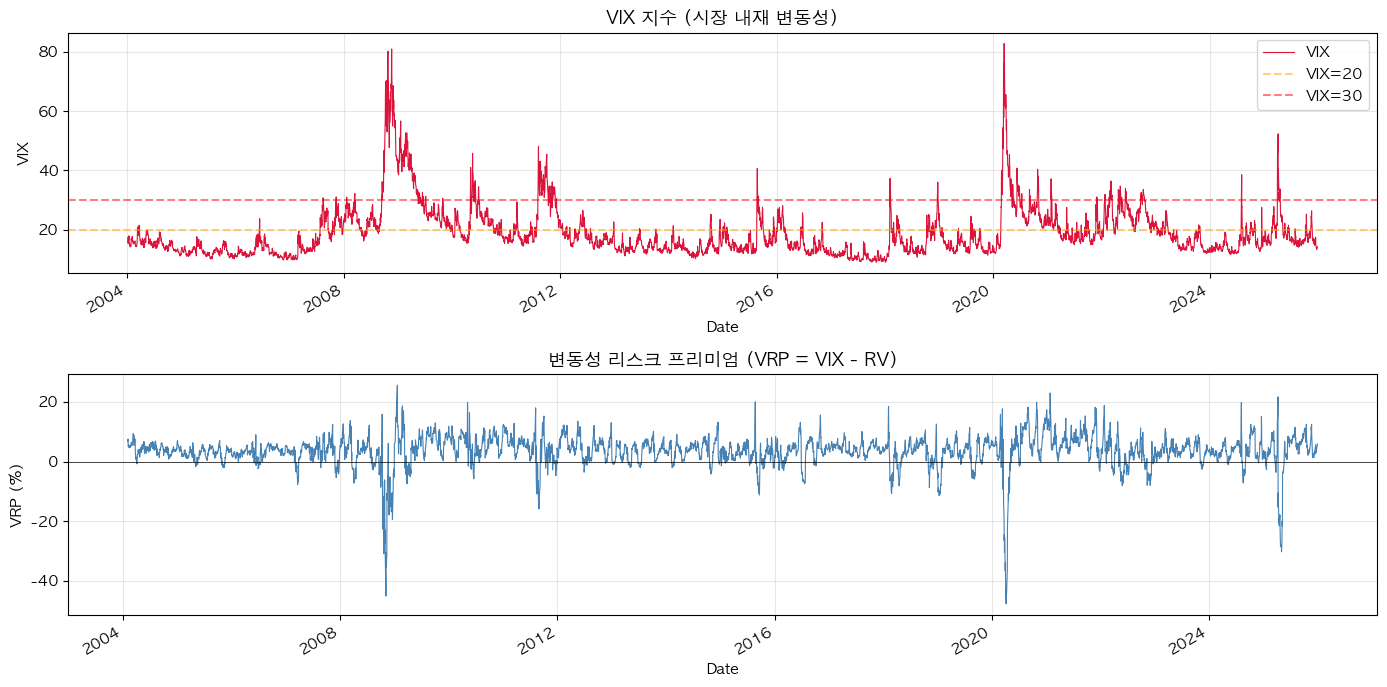

In [202]:
# ── VIX 데이터 다운로드 ────────────────────────────────────────────────────────

vix = yf.download('^VIX', start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)['Close'].squeeze()
vix = vix.reindex(returns.index).ffill()
vix_pct = vix / 100  # 소수 변환

print(f'✅ VIX 데이터 로드: {len(vix)}일')
print(f'   평균 VIX: {vix.mean():.1f}%')
print(f'   최대 VIX: {vix.max():.1f}% ({vix.idxmax().date()})')

# VIX 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
vix.plot(ax=axes[0], color='crimson', linewidth=0.8, label='VIX')
axes[0].axhline(20, color='orange', linestyle='--', alpha=0.5, label='VIX=20')
axes[0].axhline(30, color='red',    linestyle='--', alpha=0.5, label='VIX=30')
axes[0].set_title('VIX 지수 (시장 내재 변동성)')
axes[0].set_ylabel('VIX')
axes[0].legend()

# VRP = IV - RV (변동성 리스크 프리미엄)
rv_market = mkt_returns.rolling(21).std() * np.sqrt(252) * 100
vrp = vix - rv_market.reindex(vix.index)
vrp.plot(ax=axes[1], color='steelblue', linewidth=0.8)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('변동성 리스크 프리미엄 (VRP = VIX - RV)')
axes[1].set_ylabel('VRP (%)')

plt.tight_layout()
plt.show()

In [203]:
# ── 내재 변동성 기반 BL ────────────────────────────────────────────────────────

class ImpliedVolBL:
    """
    내재 변동성 (VIX) 기반 Black-Litterman
    
    개별 주식 IV 근사: beta_i * VIX (체계적 위험 부분)
    VRP = IV - RV: 양수 → 시장이 미래 리스크를 과대평가 → 하향 조정
    """

    def __init__(self, tau=TAU, delta=DELTA, window=ROLL_WINDOW,
                 vrp_scale=0.3):
        self.tau       = tau
        self.delta     = delta
        self.window    = window
        self.vrp_scale = vrp_scale

    def estimate_beta(self, ret_stock: pd.Series,
                      ret_mkt: pd.Series) -> float:
        """OLS로 베타 추정"""
        common = ret_stock.index.intersection(ret_mkt.index)
        y = ret_stock[common].values
        x = ret_mkt[common].values
        if len(y) < 30:
            return 1.0
        cov = np.cov(y, x)
        return cov[0, 1] / (cov[1, 1] + 1e-8)

    def fit_predict(self, returns_slice: pd.DataFrame,
                    mkt_ret: pd.Series, vix_slice: pd.Series):
        n     = len(returns_slice.columns)
        sigma = ledoit_wolf_cov(returns_slice).values
        w_eq  = np.ones(n) / n
        pi    = bl_implied_returns(w_eq, sigma, self.delta)

        mkt_aligned = mkt_ret.reindex(returns_slice.index).dropna()
        vix_current = vix_slice.iloc[-1] / 100  # 소수 변환

        Q = np.zeros(n)
        omega_diag = np.zeros(n)

        for i, ticker in enumerate(returns_slice.columns):
            # 베타로 개별 IV 근사
            beta_i  = self.estimate_beta(returns_slice[ticker], mkt_aligned)
            beta_i  = np.clip(beta_i, 0.1, 3.0)
            iv_i    = abs(beta_i) * vix_current   # 개별 IV 근사

            # 실현 변동성
            rv_i    = returns_slice[ticker].std() * np.sqrt(252)

            # VRP = IV - RV
            vrp_i   = iv_i - rv_i

            # Q: VRP 양수(시장 과대평가) → 뷰 하향
            Q[i]   = pi[i] - self.vrp_scale * vrp_i

            # Omega: IV 높을수록 불확실성 높음
            omega_diag[i] = self.tau * sigma[i, i] * (1 + iv_i / 0.2)

        P = np.eye(n)
        omega = np.diag(omega_diag)

        mu_bl, sigma_bl = black_litterman(pi, sigma, P, Q, omega, self.tau, self.delta)
        return mean_variance_weights(mu_bl, sigma_bl, self.delta)


print('✅ Implied Volatility BL 클래스 정의 완료')

✅ Implied Volatility BL 클래스 정의 완료


In [204]:
# ── IV 백테스트 실행 ───────────────────────────────────────────────────────────

def run_rolling_bt_iv(model, returns, mkt_returns, vix,
                      membership=None,
                      window=ROLL_WINDOW, freq='ME', label='IV-BL'):
    rebal_dates  = returns.resample(freq).last().index
    weights_list = []

    for date in tqdm(rebal_dates[window//21:], desc=f'{label} 계산중'):
        end_idx   = returns.index.searchsorted(date, side='right') - 1
        if end_idx < 0:
            continue
        start_idx = max(0, end_idx - window)
        mkt_slice = mkt_returns.iloc[start_idx:end_idx]
        vix_slice = vix.iloc[start_idx:end_idx]
        if len(vix_slice) == 0:
            continue

        if membership is not None:
            tickers = get_members_capped(date, returns, membership)
        else:
            tickers = returns.columns.tolist()
        if len(tickers) < 5:
            continue

        slice_ret = returns.iloc[start_idx:end_idx][tickers]
        slice_ret = slice_ret.dropna(axis=1, thresh=len(slice_ret) // 2).fillna(0)
        if len(slice_ret.columns) < 5:
            continue
        try:
            w = model.fit_predict(slice_ret, mkt_slice, vix_slice)
            weights_list.append({'date': date,
                                  **dict(zip(slice_ret.columns, w))})
        except Exception:
            n = len(slice_ret.columns)
            weights_list.append({'date': date,
                                  **dict(zip(slice_ret.columns, np.ones(n)/n))})

    weights_df = pd.DataFrame(weights_list).set_index('date')
    return run_backtest(weights_df, returns, label=label)


iv_model = ImpliedVolBL()
ret_iv   = run_rolling_bt_iv(iv_model, returns, mkt_returns, vix, membership=sp500_membership, label='내재변동성')

m = compute_metrics(ret_iv)
print(f'\n📊 내재변동성 BL 성능 요약')
for k, v in m.items():
    print(f'   {k}: {v}')


내재변동성 계산중:   0%|          | 0/204 [00:00<?, ?it/s]


📊 내재변동성 BL 성능 요약
   연간수익률(%): 13.69
   연간변동성(%): 16.68
   샤프비율: 0.701
   소르티노: 0.918
   MDD(%): -30.66
   Calmar: 0.446
   거래일수: 4255


In [205]:
print(ret_iv.head())

Date
2009-02-02    0.002821
2009-02-03   -0.005592
2009-02-04   -0.003158
2009-02-05    0.022483
2009-02-06    0.026656
Name: 내재변동성, dtype: float64


---
# 6. 종합 성능 비교 및 시각화

In [206]:
# ── 모든 전략 수익률 정리 ──────────────────────────────────────────────────────

ALL_STRATEGIES = {
    '동일가중(BM)'   : ew_ret,
    'Idzorek'        : ret_idzorek,
    '변동성레짐'      : ret_regime,
    '변동성스프레드'  : ret_spread,
    '변동성모멘텀'    : ret_momentum,
    'GARCH'          : ret_garch,
    'GJR-GARCH'      : ret_gjr,
    'RS(2국면)'       : ret_rs2,
    'RS(3국면)'       : ret_rs3,
    '내재변동성'      : ret_iv,
}

# 공통 기간 추출
common_start = max(s.index[0] for s in ALL_STRATEGIES.values() if len(s) > 0)
common_end   = min(s.index[-1] for s in ALL_STRATEGIES.values() if len(s) > 0)

ret_df = pd.DataFrame({
    name: series.loc[common_start:common_end]
    for name, series in ALL_STRATEGIES.items()
    if len(series) > 0
})

print(f'📊 비교 기간: {common_start.date()} ~ {common_end.date()}')
print(f'   전략 수: {len(ret_df.columns)}개')
print(f'   거래일: {len(ret_df)}일')

📊 비교 기간: 2009-02-02 ~ 2025-12-30
   전략 수: 10개
   거래일: 4255일


In [207]:
# ── 성능 지표 테이블 ───────────────────────────────────────────────────────────

metrics_data = {}
for col in ret_df.columns:
    metrics_data[col] = compute_metrics(ret_df[col])

metrics_df = pd.DataFrame(metrics_data).T
metrics_df = metrics_df.sort_values('샤프비율', ascending=False)

print('═' * 80)
print('📊 전략별 종합 성능 비교 (샤프비율 내림차순)')
print('═' * 80)
print(metrics_df.to_string())
print('═' * 80)

════════════════════════════════════════════════════════════════════════════════
📊 전략별 종합 성능 비교 (샤프비율 내림차순)
════════════════════════════════════════════════════════════════════════════════
           연간수익률(%)  연간변동성(%)   샤프비율   소르티노  MDD(%)  Calmar    거래일수
변동성스프레드       13.91     14.94  0.798  0.984  -38.39   0.362  4255.0
RS(2국면)       16.58     19.01  0.767  0.971  -38.68   0.429  4255.0
동일가중(BM)      16.56     19.00  0.766  0.971  -38.65   0.429  4255.0
Idzorek       16.56     19.00  0.766  0.971  -38.65   0.429  4255.0
RS(3국면)       16.57     19.03  0.766  0.970  -38.63   0.429  4255.0
내재변동성         13.69     16.68  0.701  0.918  -30.66   0.446  4255.0
변동성모멘텀        14.04     17.46  0.689  0.877  -39.31   0.357  4255.0
GARCH         12.84     18.04  0.601  0.774  -37.41   0.343  4255.0
GJR-GARCH     11.70     18.06  0.537  0.690  -37.47   0.312  4255.0
변동성레짐         14.82     26.24  0.489  0.607  -52.43   0.283  4255.0
═══════════════════════════════════════════════════════════════

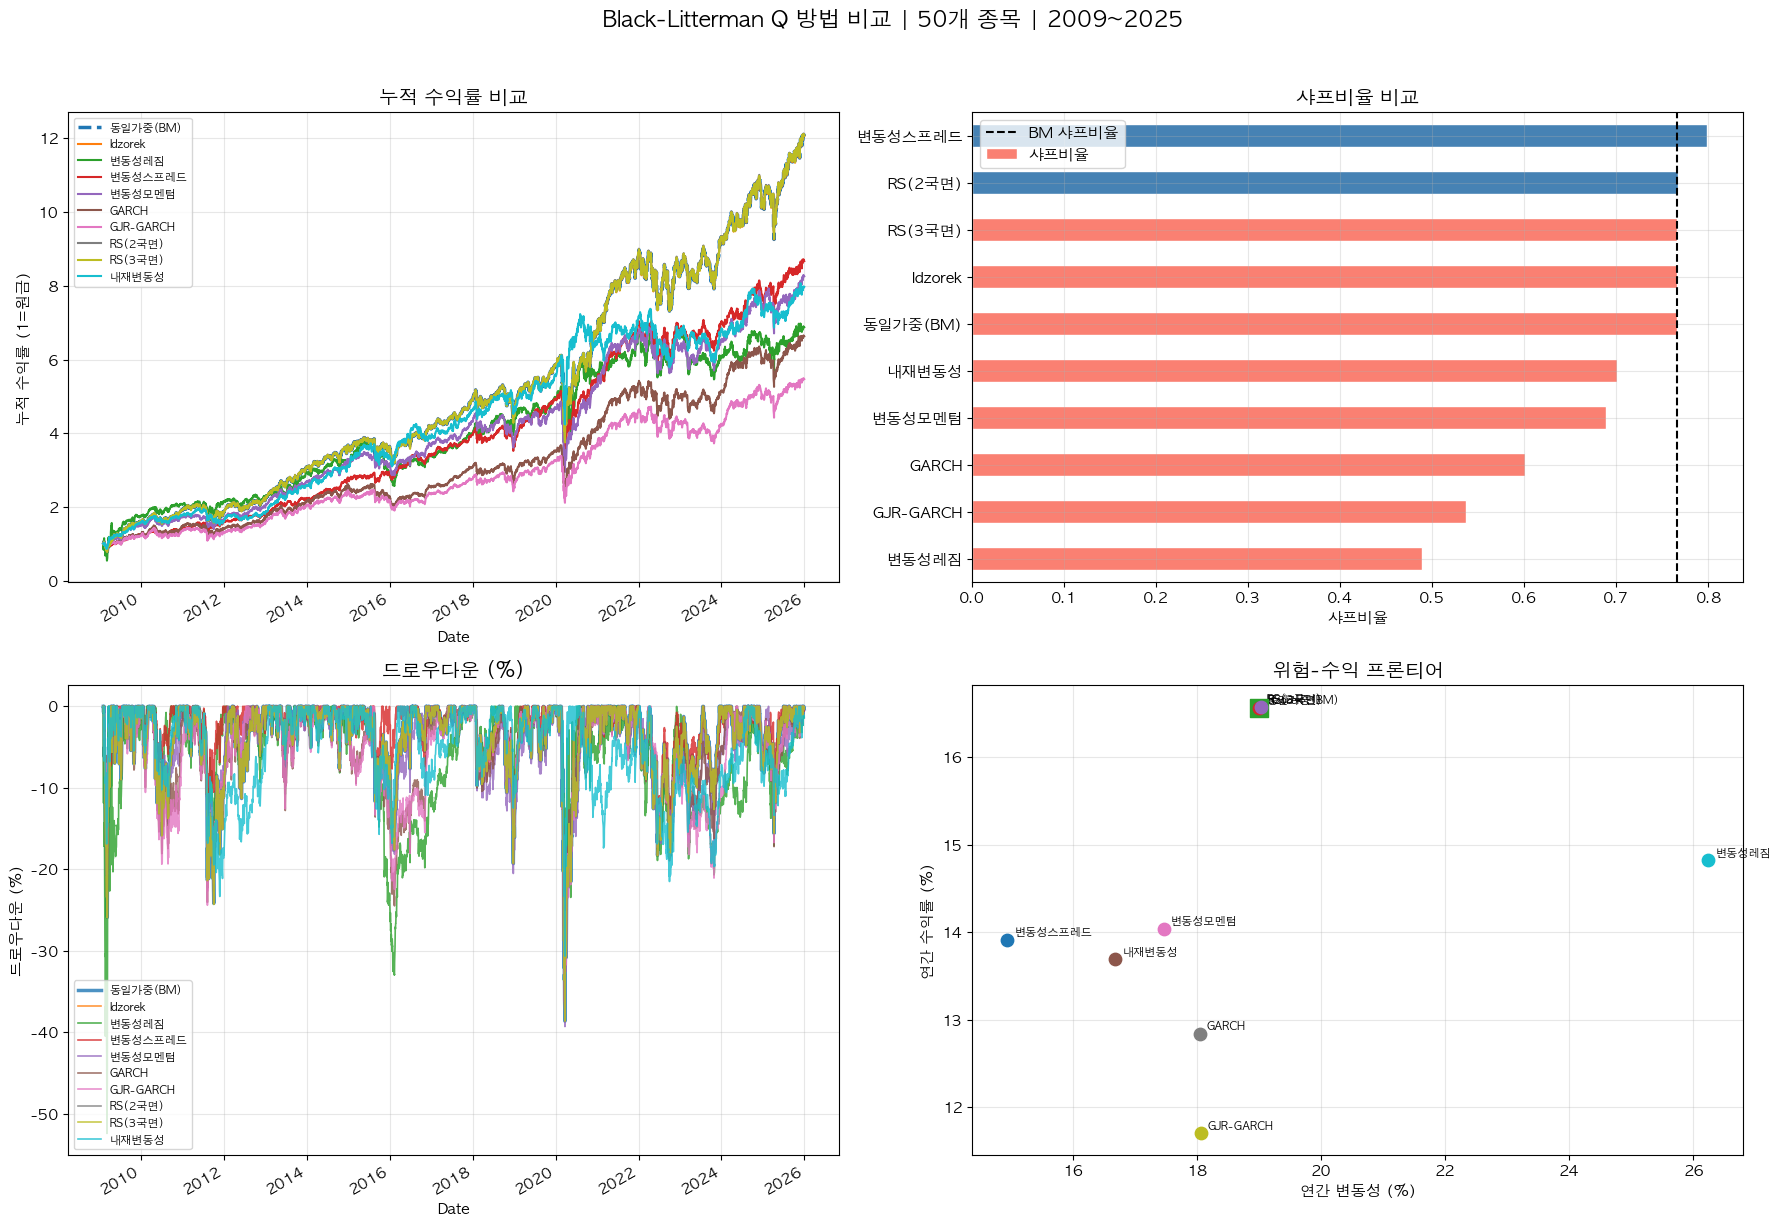

💾 차트 저장: bl_comparison_results.png


In [208]:
# ── 누적 수익률 비교 ───────────────────────────────────────────────────────────

cum_ret = (1 + ret_df).cumprod()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ① 누적 수익률
ax = axes[0, 0]
for col in cum_ret.columns:
    lw  = 2.5 if col == '동일가중(BM)' else 1.5
    ls  = '--' if col == '동일가중(BM)' else '-'
    cum_ret[col].plot(ax=ax, label=col, linewidth=lw, linestyle=ls)
ax.set_title('누적 수익률 비교', fontsize=14, fontweight='bold')
ax.set_ylabel('누적 수익률 (1=원금)')
ax.legend(loc='upper left', fontsize=8)

# ② 샤프비율 바차트
ax = axes[0, 1]
sharpe_vals = metrics_df['샤프비율'].sort_values(ascending=True)
colors_bar  = ['steelblue' if v > metrics_df.loc['동일가중(BM)', '샤프비율'] else 'salmon'
                for v in sharpe_vals]
sharpe_vals.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')
ax.axvline(metrics_df.loc['동일가중(BM)', '샤프비율'], color='black',
           linestyle='--', linewidth=1.5, label='BM 샤프비율')
ax.set_title('샤프비율 비교', fontsize=14, fontweight='bold')
ax.set_xlabel('샤프비율')
ax.legend()

# ③ 드로우다운
ax = axes[1, 0]
for col in cum_ret.columns:
    roll_max = cum_ret[col].cummax()
    dd = (cum_ret[col] - roll_max) / roll_max * 100
    lw = 2.5 if col == '동일가중(BM)' else 1.2
    dd.plot(ax=ax, label=col, linewidth=lw, alpha=0.8)
ax.set_title('드로우다운 (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('드로우다운 (%)')
ax.legend(loc='lower left', fontsize=8)

# ④ 위험-수익 산포도
ax = axes[1, 1]
for col in metrics_df.index:
    vol = metrics_df.loc[col, '연간변동성(%)']
    ret = metrics_df.loc[col, '연간수익률(%)']
    marker = 's' if col == '동일가중(BM)' else 'o'
    size   = 150 if col == '동일가중(BM)' else 80
    ax.scatter(vol, ret, s=size, marker=marker, zorder=5)
    ax.annotate(col, (vol, ret), textcoords='offset points',
                xytext=(5, 3), fontsize=8)

ax.set_title('위험-수익 프론티어', fontsize=14, fontweight='bold')
ax.set_xlabel('연간 변동성 (%)')
ax.set_ylabel('연간 수익률 (%)')

plt.suptitle(f'Black-Litterman Q 방법 비교 | {UNIVERSE_SIZE}개 종목 | {common_start.year}~{common_end.year}',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('bl_comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 차트 저장: bl_comparison_results.png')

In [209]:
# ── 위기 구간별 성능 분석 ──────────────────────────────────────────────────────

CRISIS_PERIODS = {
    'GFC(2008-09)' : ('2008-01-01', '2009-06-30'),
    '유럽재정위기' : ('2011-07-01', '2012-06-30'),
    'COVID(2020)'  : ('2020-02-01', '2020-06-30'),
    '금리상승(2022)': ('2022-01-01', '2022-12-31'),
}

crisis_results = {}
for period_name, (s, e) in CRISIS_PERIODS.items():
    mask = (ret_df.index >= s) & (ret_df.index <= e)
    if mask.sum() < 10:
        continue
    period_ret = ret_df[mask]
    period_metrics = {}
    for col in period_ret.columns:
        m = compute_metrics(period_ret[col])
        period_metrics[col] = {
            '수익률(%)': m.get('연간수익률(%)', np.nan),
            'MDD(%)': m.get('MDD(%)', np.nan),
            '샤프': m.get('샤프비율', np.nan),
        }
    crisis_results[period_name] = pd.DataFrame(period_metrics).T

print('\n📊 위기 구간별 성능 요약')
print('=' * 80)
for period_name, df in crisis_results.items():
    print(f'\n🔴 {period_name}')
    print(df.sort_values('MDD(%)', ascending=False).to_string())
print('=' * 80)


📊 위기 구간별 성능 요약

🔴 GFC(2008-09)
           수익률(%)  MDD(%)     샤프
내재변동성       60.82  -16.89  1.663
GJR-GARCH   12.75  -17.40  0.395
GARCH       17.03  -17.90  0.556
변동성스프레드     15.88  -20.04  0.605
변동성모멘텀      40.85  -20.61  1.198
동일가중(BM)    60.96  -25.90  1.318
Idzorek     60.96  -25.90  1.318
RS(2국면)     61.88  -25.94  1.330
RS(3국면)     61.88  -25.94  1.330
변동성레짐      161.12  -52.43  1.270

🔴 유럽재정위기
           수익률(%)  MDD(%)     샤프
변동성스프레드     12.26  -13.70  0.626
변동성레짐        6.49  -16.18  0.210
변동성모멘텀       8.27  -20.17  0.295
GARCH        5.43  -21.54  0.133
GJR-GARCH    7.01  -22.27  0.195
내재변동성       -7.93  -22.70 -0.476
동일가중(BM)     3.62  -23.58  0.061
Idzorek      3.62  -23.58  0.061
RS(2국면)      3.73  -23.63  0.065
RS(3국면)      3.58  -23.71  0.059

🔴 COVID(2020)
           수익률(%)  MDD(%)     샤프
변동성레짐       21.24  -24.22  0.328
내재변동성       44.64  -30.66  0.879
GARCH        4.98  -37.41  0.060
GJR-GARCH   -5.58  -37.47 -0.151
변동성스프레드     -5.52  -38.39 -0.145
RS(3국면)     -1.17  

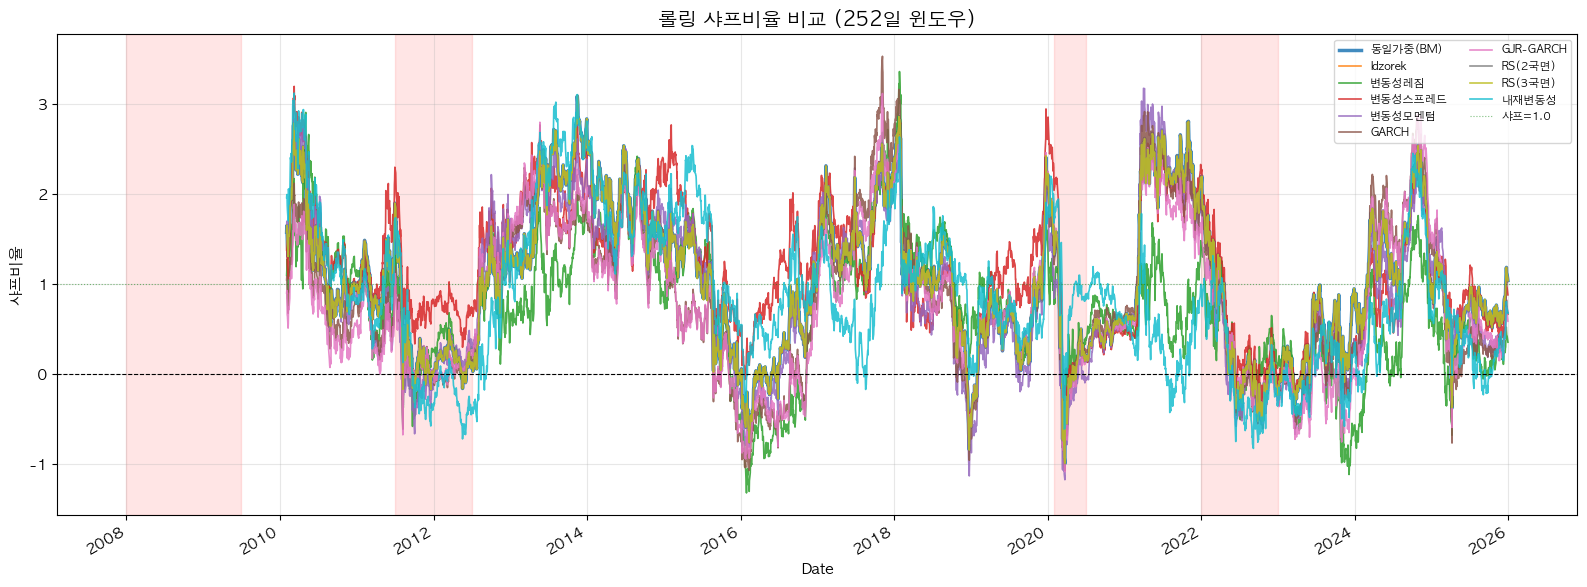

In [210]:
# ── 롤링 샤프비율 비교 ────────────────────────────────────────────────────────

ROLLING_SHARPE_WINDOW = 252  # 1년

fig, ax = plt.subplots(figsize=(16, 6))

rolling_sharpe = (
    ret_df.rolling(ROLLING_SHARPE_WINDOW)
    .apply(lambda x: (x.mean() * 252) / (x.std() * np.sqrt(252) + 1e-8))
)

for col in rolling_sharpe.columns:
    lw = 2.5 if col == '동일가중(BM)' else 1.2
    rolling_sharpe[col].plot(ax=ax, label=col, linewidth=lw, alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(1, color='green', linewidth=0.8, linestyle=':', alpha=0.5, label='샤프=1.0')
ax.set_title(f'롤링 샤프비율 비교 ({ROLLING_SHARPE_WINDOW}일 윈도우)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('샤프비율')
ax.legend(loc='upper right', fontsize=8, ncol=2)

# 위기 구간 음영
for period_name, (s, e) in CRISIS_PERIODS.items():
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
               alpha=0.1, color='red', label=f'_{period_name}')

plt.tight_layout()
plt.show()

---
# 7. 유니버스 크기별 비교 실험

50 / 100 / 500개 종목에 대해 대표 방법론(Idzorek, GARCH, RS)을 비교합니다.

In [211]:
# ── 유니버스 구성 검증 (생존편향 없는 동적 유니버스) ──────────────────────────

print('📋 유니버스 크기별 선택 종목 비교 (특정 날짜 기준 예시)')
print('=' * 60)

test_date = pd.Timestamp('2015-06-30')
universe_tickers = {}
for n in UNIVERSE_SIZES:
    t = get_top_members(test_date, returns, sp500_membership, n=n)
    universe_tickers[n] = set(t)
    print(f'  {n}개 유니버스 ({test_date.date()} 기준): {t[:8]}...')

u50  = universe_tickers[UNIVERSE_SIZES[0]]
u100 = universe_tickers[UNIVERSE_SIZES[1]]
overlap = len(u50 & u100)
print(f'\n  50개 ∩ 100개 겹치는 종목: {overlap}개')
print(f'  → 50개가 100개의 부분집합: {u50.issubset(u100)}')
print(f'  (True면 정상: 작은 유니버스 ⊂ 큰 유니버스)')
print()
print('✅ 생존편향 없는 동적 유니버스 검증 완료')


📋 유니버스 크기별 선택 종목 비교 (특정 날짜 기준 예시)
  50개 유니버스 (2015-06-30 기준): ['ECL', 'NRG', 'VTRS', 'GIS', 'NI', 'ADM', 'REGN', 'F']...
  100개 유니버스 (2015-06-30 기준): ['ECL', 'NRG', 'VTRS', 'GIS', 'NI', 'ADM', 'REGN', 'F']...
  500개 유니버스 (2015-06-30 기준): ['ECL', 'DIS', 'ATI', 'AMAT', 'CMCSA', 'RF', 'RL', 'LLY']...

  50개 ∩ 100개 겹치는 종목: 50개
  → 50개가 100개의 부분집합: True
  (True면 정상: 작은 유니버스 ⊂ 큰 유니버스)

✅ 생존편향 없는 동적 유니버스 검증 완료


In [212]:
# ── 유니버스 크기별 실험 (생존편향 없는 동적 유니버스) ───────────────────────

UNIVERSE_RESULTS = {}

def make_repr_models():
    return {
        'Idzorek'    : IdzorekBL(),
        '변동성레짐'  : VolRegimeBL(),
        '변동성모멘텀': VolMomentumBL(),
    }

for n_stocks in UNIVERSE_SIZES:
    print(f'\n{"="*50}')
    print(f'🔬 유니버스 크기: {n_stocks}개 (당시 S&P500 멤버 중 상위 {n_stocks}개)')
    print(f'{"="*50}')

    universe_res = {}

    # 동적 동일가중 벤치마크 (멤버십 기반)
    _rebal_idx = returns.resample('ME').last().index[ROLL_WINDOW // 21:]
    _ew_rows = []
    for _date in _rebal_idx:
        _tickers = get_top_members(_date, returns, sp500_membership, n=n_stocks)
        if _tickers:
            _n = len(_tickers)
            _ew_rows.append({'date': _date, **{t: 1 / _n for t in _tickers}})
    _ew_hist = pd.DataFrame(_ew_rows).set_index('date')
    universe_res['동일가중'] = run_backtest(_ew_hist, returns, label='동일가중')

    repr_models = make_repr_models()

    # 각 모델 롤링 백테스트 — get_top_members로 상위 N개 선택
    def run_rolling_top_n(model, returns, membership, n, window=ROLL_WINDOW, freq='ME', label='BL'):
        rebal_dates  = returns.resample(freq).last().index
        weights_list = []
        for date in tqdm(rebal_dates[window // 21:], desc=f'{label} 계산중'):
            end_idx = returns.index.searchsorted(date, side='right') - 1
            if end_idx < 0:
                continue
            start_idx = max(0, end_idx - window)
            tickers = get_top_members(date, returns, membership, n=n, min_obs=window // 2)
            if len(tickers) < 5:
                continue
            slice_ret = returns.iloc[start_idx:end_idx][tickers]
            slice_ret = slice_ret.dropna(axis=1, thresh=len(slice_ret) // 2).fillna(0)
            if len(slice_ret.columns) < 5:
                continue
            try:
                w = model.fit_predict(slice_ret)
                weights_list.append({'date': date, **dict(zip(slice_ret.columns, w))})
            except Exception:
                nn = len(slice_ret.columns)
                weights_list.append({'date': date,
                                     **dict(zip(slice_ret.columns, np.ones(nn) / nn))})
        weights_df = pd.DataFrame(weights_list).set_index('date')
        return run_backtest(weights_df, returns, label=label)

    for model_name, model in repr_models.items():
        ret_tmp = run_rolling_top_n(model, returns, sp500_membership, n=n_stocks, label=model_name)
        universe_res[model_name] = ret_tmp

    UNIVERSE_RESULTS[n_stocks] = universe_res

    for sname, sret in universe_res.items():
        m = compute_metrics(sret)
        print(f'  {sname:12s}: 샤프={m.get("샤프비율","N/A"):6.3f}, '
              f'연수익={m.get("연간수익률(%)","N/A"):6.2f}%, '
              f'MDD={m.get("MDD(%)","N/A"):6.2f}%')

print('\n✅ 유니버스 크기별 실험 완료')



🔬 유니버스 크기: 50개 (당시 S&P500 멤버 중 상위 50개)


Idzorek 계산중:   0%|          | 0/204 [00:00<?, ?it/s]

변동성레짐 계산중:   0%|          | 0/204 [00:00<?, ?it/s]

변동성모멘텀 계산중:   0%|          | 0/204 [00:00<?, ?it/s]

  동일가중        : 샤프= 0.769, 연수익= 16.23%, MDD=-36.06%
  Idzorek     : 샤프= 0.769, 연수익= 16.23%, MDD=-36.06%
  변동성레짐       : 샤프= 0.465, 연수익= 12.28%, MDD=-44.34%
  변동성모멘텀      : 샤프= 0.705, 연수익= 14.24%, MDD=-34.77%

🔬 유니버스 크기: 100개 (당시 S&P500 멤버 중 상위 100개)


...

  동일가중        : 샤프= 0.766, 연수익= 16.56%, MDD=-38.65%
  Idzorek     : 샤프= 0.766, 연수익= 16.56%, MDD=-38.65%
  변동성레짐       : 샤프= 0.489, 연수익= 14.82%, MDD=-52.43%
  변동성모멘텀      : 샤프= 0.689, 연수익= 14.04%, MDD=-39.31%

🔬 유니버스 크기: 500개 (당시 S&P500 멤버 중 상위 500개)


Idzorek 계산중:   0%|          | 0/204 [00:00<?, ?it/s]

변동성레짐 계산중:   0%|          | 0/204 [00:00<?, ?it/s]

변동성모멘텀 계산중:   0%|          | 0/204 [00:00<?, ?it/s]

  동일가중        : 샤프= 0.773, 연수익= 16.93%, MDD=-39.82%
  Idzorek     : 샤프= 0.773, 연수익= 16.93%, MDD=-39.82%
  변동성레짐       : 샤프= 0.613, 연수익= 14.10%, MDD=-32.80%
  변동성모멘텀      : 샤프= 0.705, 연수익= 13.56%, MDD=-41.16%

✅ 유니버스 크기별 실험 완료


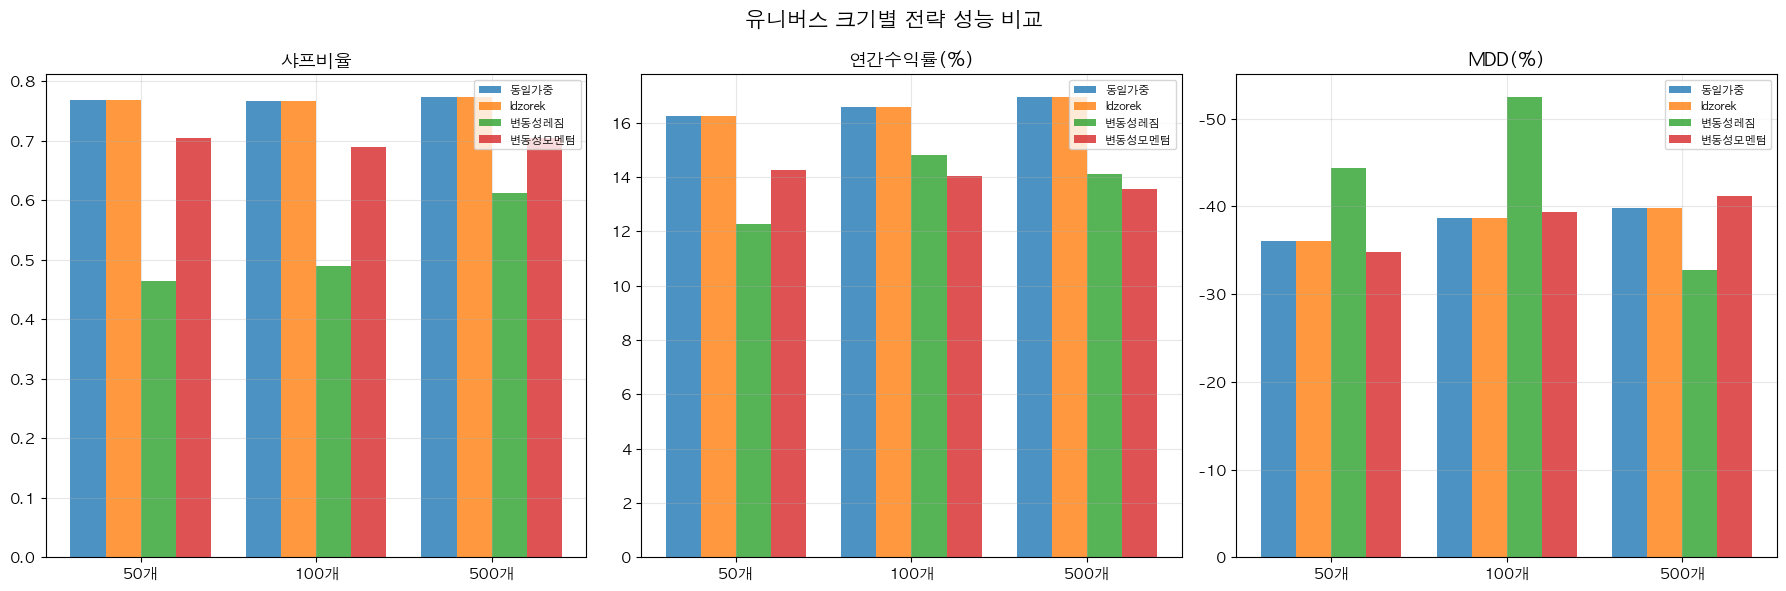

In [213]:
# ── 유니버스 크기별 비교 시각화 ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics_to_plot = ['샤프비율', '연간수익률(%)', 'MDD(%)']
universe_summary = {}

for n_stocks, results in UNIVERSE_RESULTS.items():
    for strat, ret in results.items():
        m = compute_metrics(ret)
        key = (n_stocks, strat)
        universe_summary[key] = m

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    strategies = list(next(iter(UNIVERSE_RESULTS.values())).keys())
    x = np.arange(len(UNIVERSE_SIZES))
    width = 0.8 / len(strategies)

    for j, strat in enumerate(strategies):
        vals = [
            universe_summary.get((n, strat), {}).get(metric, np.nan)
            for n in UNIVERSE_SIZES
        ]
        offset = (j - len(strategies)/2 + 0.5) * width
        bars = ax.bar(x + offset, vals, width,
                      label=strat, alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels([f'{n}개' for n in UNIVERSE_SIZES])
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.legend(fontsize=8)
    if metric == 'MDD(%)':
        ax.invert_yaxis()  # MDD는 작을수록 좋음

plt.suptitle('유니버스 크기별 전략 성능 비교', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
# 8. 파라미터 민감도 분석 (Sensitivity Analysis)

🔍 tau 민감도 분석 중...


tau 실험:   0%|          | 0/5 [00:00<?, ?it/s]

tau=0.01 계산중:   0%|          | 0/204 [00:00<?, ?it/s]

tau=0.025 계산중:   0%|          | 0/204 [00:00<?, ?it/s]

tau=0.05 계산중:   0%|          | 0/204 [00:00<?, ?it/s]

...

delta=2.0 계산중:   0%|          | 0/204 [00:00<?, ?it/s]

delta=2.5 계산중:   0%|          | 0/204 [00:00<?, ?it/s]

delta=3.0 계산중:   0%|          | 0/204 [00:00<?, ?it/s]

delta=4.0 계산중:   0%|          | 0/204 [00:00<?, ?it/s]

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


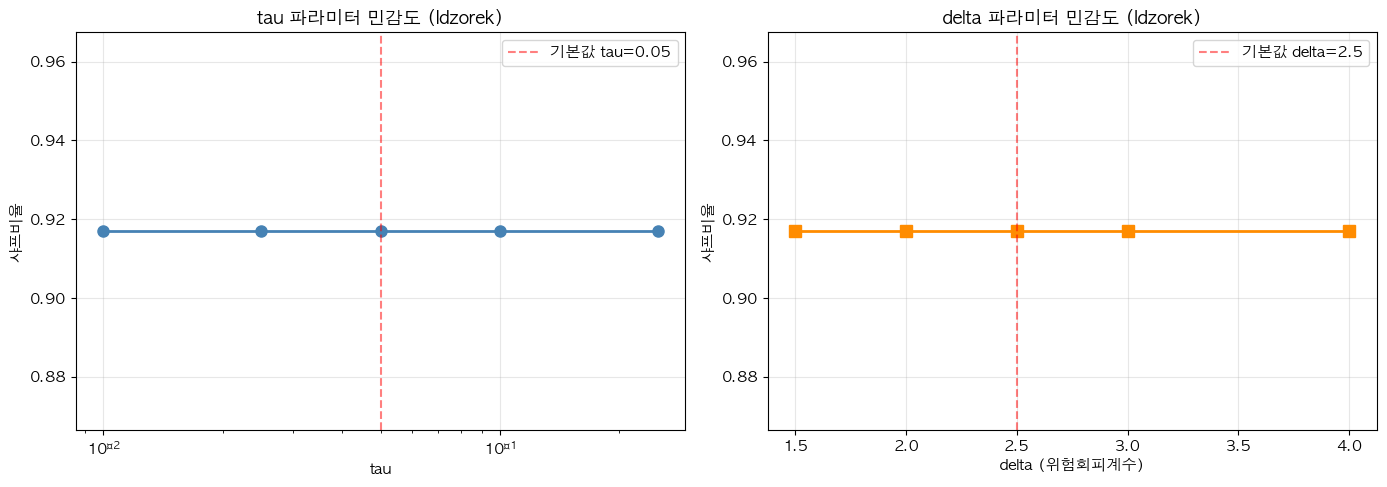


📊 tau 민감도 결과:
        샤프비율  연간수익률(%)  MDD(%)
0.010  0.917     19.78  -39.16
0.025  0.917     19.78  -39.16
0.050  0.917     19.78  -39.16
0.100  0.917     19.78  -39.16
0.250  0.917     19.78  -39.16


In [214]:
# ── tau 민감도 분석 ────────────────────────────────────────────────────────────

TAU_GRID   = [0.01, 0.025, 0.05, 0.1, 0.25]
DELTA_GRID = [1.5, 2.0, 2.5, 3.0, 4.0]

tau_results   = {}
delta_results = {}

print('🔍 tau 민감도 분석 중...')
for tau_val in tqdm(TAU_GRID, desc='tau 실험'):
    model_tmp = IdzorekBL(tau=tau_val, delta=DELTA)
    ret_tmp   = run_rolling_backtest(model_tmp, returns,
                                      window=ROLL_WINDOW,
                                      label=f'tau={tau_val}')
    tau_results[tau_val] = compute_metrics(ret_tmp)

print('\n🔍 delta 민감도 분석 중...')
for delta_val in tqdm(DELTA_GRID, desc='delta 실험'):
    model_tmp = IdzorekBL(tau=TAU, delta=delta_val)
    ret_tmp   = run_rolling_backtest(model_tmp, returns,
                                      window=ROLL_WINDOW,
                                      label=f'delta={delta_val}')
    delta_results[delta_val] = compute_metrics(ret_tmp)

# 결과 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# tau 민감도
ax = axes[0]
sharpe_tau = [tau_results[t].get('샤프비율', np.nan) for t in TAU_GRID]
ax.plot(TAU_GRID, sharpe_tau, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.axvline(TAU, color='red', linestyle='--', alpha=0.5, label=f'기본값 tau={TAU}')
ax.set_title('tau 파라미터 민감도 (Idzorek)', fontsize=13, fontweight='bold')
ax.set_xlabel('tau')
ax.set_ylabel('샤프비율')
ax.set_xscale('log')
ax.legend()

# delta 민감도
ax = axes[1]
sharpe_delta = [delta_results[d].get('샤프비율', np.nan) for d in DELTA_GRID]
ax.plot(DELTA_GRID, sharpe_delta, 's-', color='darkorange', linewidth=2, markersize=8)
ax.axvline(DELTA, color='red', linestyle='--', alpha=0.5, label=f'기본값 delta={DELTA}')
ax.set_title('delta 파라미터 민감도 (Idzorek)', fontsize=13, fontweight='bold')
ax.set_xlabel('delta (위험회피계수)')
ax.set_ylabel('샤프비율')
ax.legend()

plt.tight_layout()
plt.show()

print('\n📊 tau 민감도 결과:')
print(pd.DataFrame(tau_results).T[['샤프비율', '연간수익률(%)', 'MDD(%)']].to_string())

---
# 9. 최종 종합 결론 및 권고사항

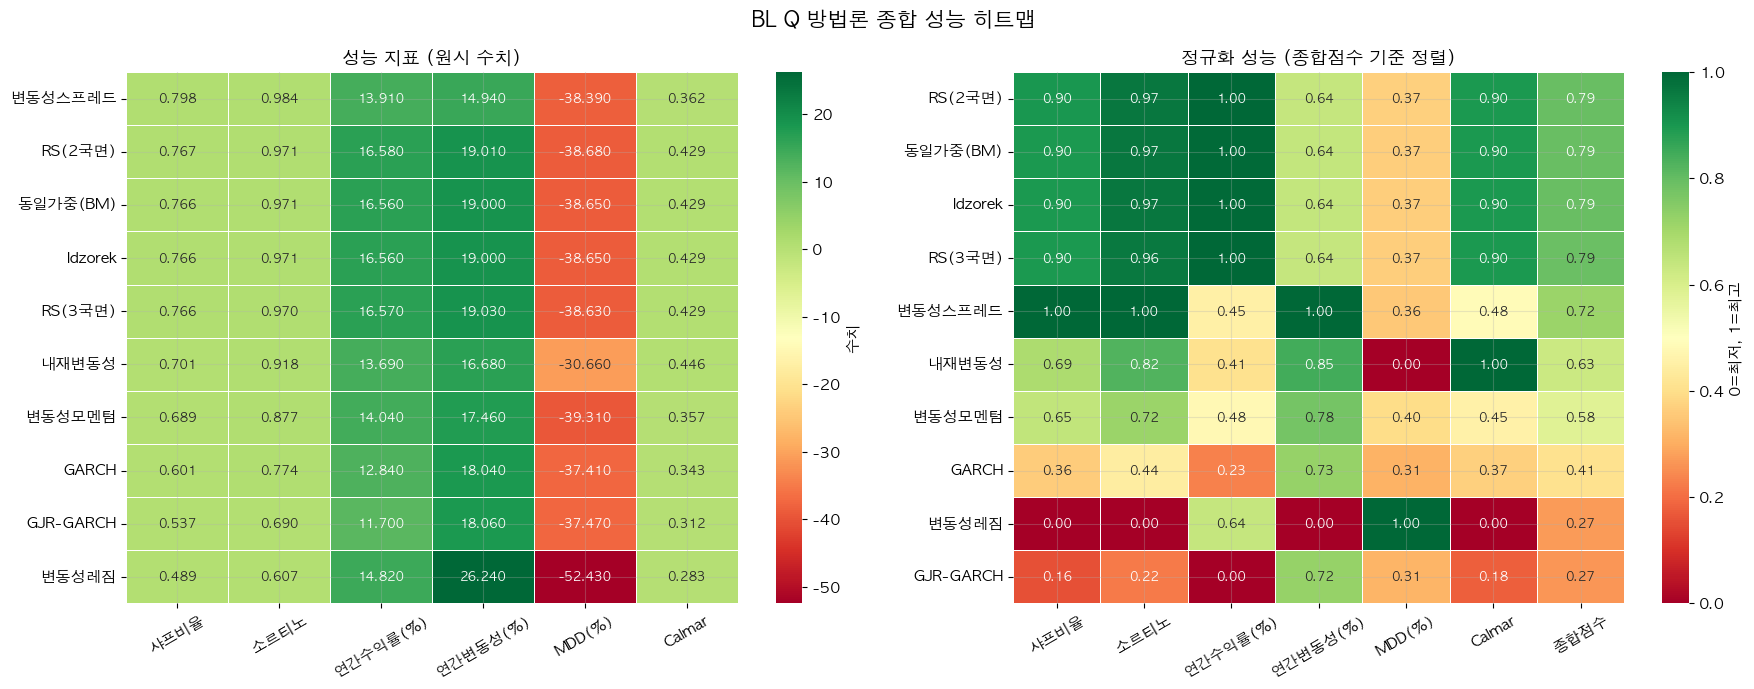

In [215]:
# ── 최종 성능 히트맵 ──────────────────────────────────────────────────────────

summary_metrics = ['샤프비율', '소르티노', '연간수익률(%)', '연간변동성(%)', 'MDD(%)', 'Calmar']
final_table = metrics_df[summary_metrics].copy()

# 정규화 (0~1, 높을수록 좋음)
normalized = final_table.copy()
for col in ['샤프비율', '소르티노', '연간수익률(%)', 'Calmar']:
    mn, mx = normalized[col].min(), normalized[col].max()
    normalized[col] = (normalized[col] - mn) / (mx - mn + 1e-8)

for col in ['연간변동성(%)', 'MDD(%)']:  # 낮을수록 좋음
    mn, mx = normalized[col].min(), normalized[col].max()
    normalized[col] = 1 - (normalized[col] - mn) / (mx - mn + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 원시 수치 히트맵
ax = axes[0]
sns.heatmap(final_table.astype(float), annot=True, fmt='.3f',
            cmap='RdYlGn', ax=ax, linewidths=0.5,
            cbar_kws={'label': '수치'},
            annot_kws={'size': 9})
ax.set_title('성능 지표 (원시 수치)', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30)

# 정규화 히트맵
ax = axes[1]
normalized['종합점수'] = normalized.mean(axis=1)
normalized_sorted = normalized.sort_values('종합점수', ascending=False)
sns.heatmap(normalized_sorted.astype(float), annot=True, fmt='.2f',
            cmap='RdYlGn', ax=ax, linewidths=0.5,
            vmin=0, vmax=1,
            cbar_kws={'label': '0=최저, 1=최고'},
            annot_kws={'size': 9})
ax.set_title('정규화 성능 (종합점수 기준 정렬)', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30)

plt.suptitle('BL Q 방법론 종합 성능 히트맵', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('bl_heatmap_final.png', dpi=150, bbox_inches='tight')
plt.show()

In [216]:
# ── 최종 결론 출력 ─────────────────────────────────────────────────────────────

best_strategy = normalized_sorted.index[0]
best_score    = normalized_sorted['종합점수'].iloc[0]

print('=' * 70)
print('🏆 Black-Litterman Q 방법론 비교 최종 결론')
print('=' * 70)

print(f'\n📌 종합 1위: {best_strategy} (정규화 점수: {best_score:.3f})')

print('\n📊 종합 순위:')
for rank, (strat, row) in enumerate(normalized_sorted.iterrows(), 1):
    original = final_table.loc[strat]
    print(f'  {rank:2d}위 {strat:15s} | '
          f'종합점수: {row["종합점수"]:.3f} | '
          f'샤프: {original["샤프비율"]:6.3f} | '
          f'연수익: {original["연간수익률(%)"]:.2f}% | '
          f'MDD: {original["MDD(%)"]:.2f}%')

print('\n💡 방법론별 활용 권고:')
recommendations = [
    ('Idzorek',       '✅ 베이스라인으로 항상 포함. 가장 안정적이고 해석 용이'),
    ('GARCH/GJR',     '✅ 변동성 예측의 핵심. 클러스터링 효과 포착에 최적'),
    ('RS(2국면)',      '✅ 위기/안정 구간 구분에 효과적. 거시적 뷰에 활용'),
    ('내재변동성',     '⚠️ 전향적이나 데이터 비용 주의. VIX 근사 활용 권장'),
    ('변동성레짐',     '✅ 구현 쉽고 직관적. 레짐 경계 임의성 주의'),
    ('변동성스프레드', '✅ 횡단면 상대 신호에 유리. λ 파라미터 튜닝 필요'),
    ('변동성모멘텀',   '✅ 추세 추종에 효과적. 급반전 구간 주의'),
]
for name, rec in recommendations:
    print(f'  • {name:15s}: {rec}')

print('\n🔧 파라미터 권고:')
best_tau   = max(tau_results, key=lambda t: tau_results[t].get('샤프비율', -999))
best_delta = max(delta_results, key=lambda d: delta_results[d].get('샤프비율', -999))
print(f'  • tau   최적값: {best_tau} (샤프: {tau_results[best_tau].get("샤프비율","N/A")})')
print(f'  • delta 최적값: {best_delta} (샤프: {delta_results[best_delta].get("샤프비율","N/A")})')

print('=' * 70)

🏆 Black-Litterman Q 방법론 비교 최종 결론

📌 종합 1위: RS(2국면) (정규화 점수: 0.795)

📊 종합 순위:
   1위 RS(2국면)         | 종합점수: 0.795 | 샤프:  0.767 | 연수익: 16.58% | MDD: -38.68%
   2위 동일가중(BM)        | 종합점수: 0.794 | 샤프:  0.766 | 연수익: 16.56% | MDD: -38.65%
   3위 Idzorek         | 종합점수: 0.794 | 샤프:  0.766 | 연수익: 16.56% | MDD: -38.65%
   4위 RS(3국면)         | 종합점수: 0.793 | 샤프:  0.766 | 연수익: 16.57% | MDD: -38.63%
   5위 변동성스프레드         | 종합점수: 0.715 | 샤프:  0.798 | 연수익: 13.91% | MDD: -38.39%
   6위 내재변동성           | 종합점수: 0.627 | 샤프:  0.701 | 연수익: 13.69% | MDD: -30.66%
   7위 변동성모멘텀          | 종합점수: 0.579 | 샤프:  0.689 | 연수익: 14.04% | MDD: -39.31%
   8위 GARCH           | 종합점수: 0.407 | 샤프:  0.601 | 연수익: 12.84% | MDD: -37.41%
   9위 변동성레짐           | 종합점수: 0.273 | 샤프:  0.489 | 연수익: 14.82% | MDD: -52.43%
  10위 GJR-GARCH       | 종합점수: 0.265 | 샤프:  0.537 | 연수익: 11.70% | MDD: -37.47%

💡 방법론별 활용 권고:
  • Idzorek        : ✅ 베이스라인으로 항상 포함. 가장 안정적이고 해석 용이
  • GARCH/GJR      : ✅ 변동성 예측의 핵심. 클러스터링 효과 포착에 최적
  • RS(2국면)        : ✅ 위

🏅 앙상블 대상 (상위 3개): ['RS(2국면)', '동일가중(BM)', 'Idzorek']

📊 앙상블 vs 벤치마크:
           샤프비율   소르티노  연간수익률(%)  MDD(%)  Calmar
앙상블(상위3)  0.766  0.971     16.57  -38.66   0.429
동일가중(BM)  0.766  0.971     16.56  -38.65   0.429


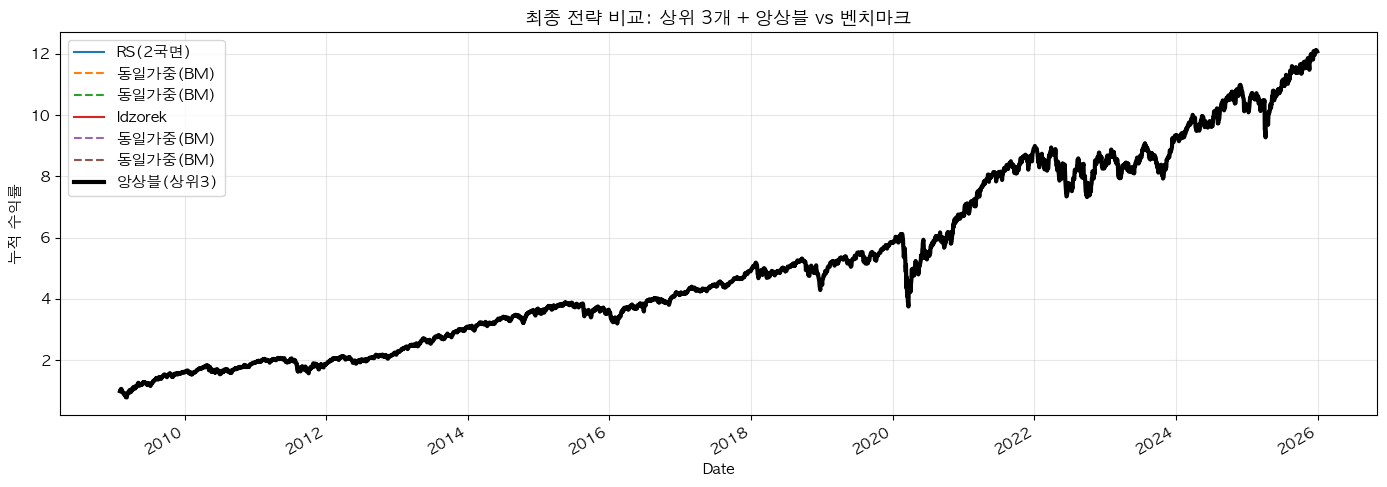


✅ 모든 분석 완료!


In [217]:
# ── 전략 앙상블 (상위 3개 전략 평균) ─────────────────────────────────────────

top3 = normalized_sorted.head(3).index.tolist()
print(f'🏅 앙상블 대상 (상위 3개): {top3}')

# 동일 가중 앙상블
ensemble_ret = ret_df[top3].mean(axis=1)
ensemble_ret.name = '앙상블(상위3)'

# 결과 비교
ens_metrics = compute_metrics(ensemble_ret)
bm_metrics2 = compute_metrics(ret_df['동일가중(BM)'])

print('\n📊 앙상블 vs 벤치마크:')
compare = pd.DataFrame([ens_metrics, bm_metrics2],
                        index=['앙상블(상위3)', '동일가중(BM)'])
print(compare[['샤프비율', '소르티노', '연간수익률(%)', 'MDD(%)', 'Calmar']].to_string())

# 누적 수익률 최종 비교
fig, ax = plt.subplots(figsize=(14, 5))
cum_final = (1 + ret_df[top3 + ['동일가중(BM)']]).cumprod()
cum_ens   = (1 + ensemble_ret.reindex(cum_final.index)).cumprod()

for col in cum_final.columns:
    ls = '--' if '동일가중' in col else '-'
    cum_final[col].plot(ax=ax, label=col, linestyle=ls, linewidth=1.5)

cum_ens.plot(ax=ax, label='앙상블(상위3)', linewidth=3,
             color='black', linestyle='-')

ax.set_title('최종 전략 비교: 상위 3개 + 앙상블 vs 벤치마크',
             fontsize=13, fontweight='bold')
ax.set_ylabel('누적 수익률')
ax.legend()
plt.tight_layout()
plt.show()

print('\n✅ 모든 분석 완료!')

---
# 부록: HMM 피처 분포 / Q별 IC·Long-Short·분포 비교


📊 HMM 2국면 분류 결과
  Bull (state=0):  3714일 ( 67.9%)  평균 체류 128일 (6.1개월)
  Bear (state=1):  1757일 ( 32.1%)  평균 체류 63일 (3.0개월)


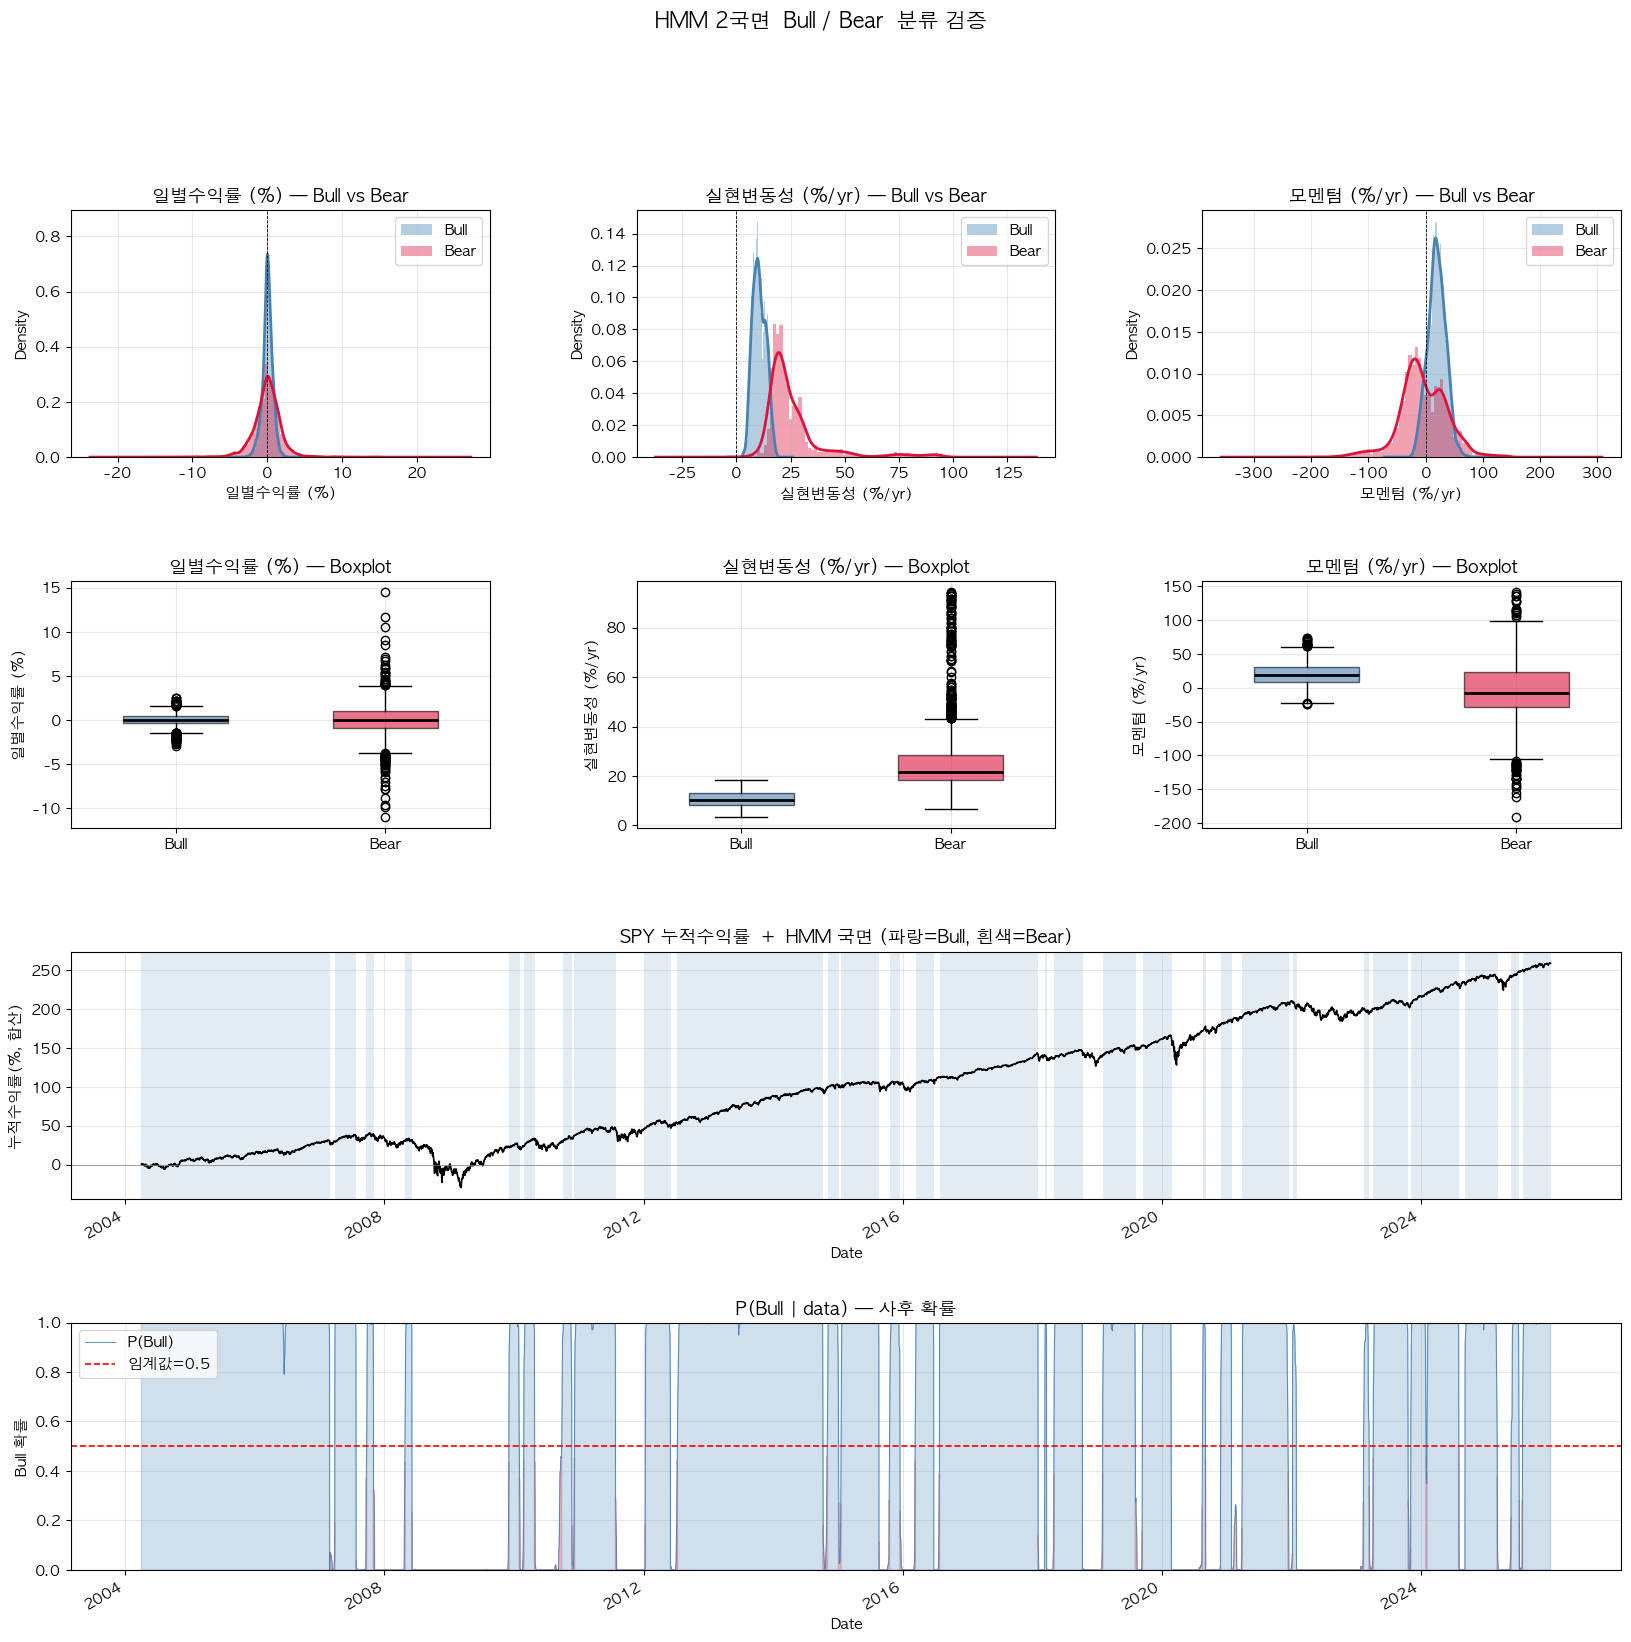


📊 국면별 피처 통계 비교

[일별수익률 (%)]  ⚠️  Bull 수익률>0, Bear 수익률<0
  Bull:  평균=  +0.067,  std=0.678,  중앙=  +0.077
  Bear:  평균=  +0.006,  std=1.846,  중앙=  +0.056
  Bull-Bear 차이: +0.061

[실현변동성 (%/yr)]  ✅  Bear 변동성 > Bull 변동성
  Bull:  평균= +10.612,  std=2.985,  중앙= +10.356
  Bear:  평균= +25.902,  std=13.930,  중앙= +21.481
  Bull-Bear 차이: -15.290

[모멘텀 (%/yr)]  ✅  Bull 모멘텀 > Bear 모멘텀
  Bull:  평균= +19.356,  std=15.572,  중앙= +19.173
  Bear:  평균=  -4.020,  std=41.085,  중앙=  -7.875
  Bull-Bear 차이: +23.376


⚠️ 일부 피처 방향 불일치 → 분류 재검토 필요


In [218]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 분석 A: HMM 2국면 — Bull/Bear 분류 검증 (피처 분포 비교)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── 피처 계산 (RegimeSwitchingBL.fit_hmm 와 동일한 방식) ─────────────────────
_rv  = mkt_returns.rolling(21).std()  * np.sqrt(252)
_mom = mkt_returns.rolling(63).mean() * 252

features = pd.DataFrame({
    'ret': mkt_returns,
    'vol': _rv,
    'mom': _mom,
}).dropna()

X = StandardScaler().fit_transform(features.values)

# ── 2국면 HMM 학습 ────────────────────────────────────────────────────────────
hmm2 = hmm.GaussianHMM(n_components=2, covariance_type='full',
                        n_iter=100, random_state=RANDOM_SEED)
hmm2.fit(X)

states     = hmm2.predict(X)
posteriors = hmm2.predict_proba(X)

# Bull = 평균 일별수익률이 높은 상태
state_ret  = [features['ret'][states == s].mean() for s in range(2)]
bull_state = int(np.argmax(state_ret))
bear_state = 1 - bull_state

features['state']     = states
features['bull_prob'] = posteriors[:, bull_state]

SLBL  = {bull_state: 'Bull', bear_state: 'Bear'}
SLCOL = {bull_state: 'steelblue', bear_state: 'crimson'}

# ── 국면 기초 통계 ────────────────────────────────────────────────────────────
print('\n📊 HMM 2국면 분류 결과')
print('='*60)
for s, lbl in SLBL.items():
    mask = states == s
    n_s  = mask.sum()
    durs = []
    cnt  = 0
    for v in mask:
        if v:       cnt += 1
        elif cnt>0: durs.append(cnt); cnt=0
    if cnt > 0: durs.append(cnt)
    avg_d = np.mean(durs) if durs else 0
    print(f'  {lbl:4s} (state={s}): {n_s:5d}일 ({n_s/len(states)*100:5.1f}%)'
          f'  평균 체류 {avg_d:.0f}일 ({avg_d/21:.1f}개월)')
print('='*60)

# ── 피처 메타 ─────────────────────────────────────────────────────────────────
FEAT_META = [
    ('ret', '일별수익률 (%)',   100),
    ('vol', '실현변동성 (%/yr)', 100),
    ('mom', '모멘텀 (%/yr)',    100),
]

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
fig = plt.figure(figsize=(20, 20))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.5, wspace=0.35)

# ① 히스토그램 + KDE — Bull vs Bear 겹쳐 그리기 ─────────────────────────────
for ci, (feat, label, scale) in enumerate(FEAT_META):
    ax = fig.add_subplot(gs[0, ci])
    for s, lbl in SLBL.items():
        data = features.loc[features['state']==s, feat] * scale
        ax.hist(data, bins=60, density=True, alpha=0.40,
                color=SLCOL[s], label=lbl, edgecolor='none')
        data.plot.kde(ax=ax, color=SLCOL[s], linewidth=2.0,
                      bw_method=0.2, label='_nolegend_')
    ax.axvline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title(f'{label} — Bull vs Bear', fontweight='bold')
    ax.set_xlabel(label)
    ax.legend()

# ② 박스플롯 ─────────────────────────────────────────────────────────────────
for ci, (feat, label, scale) in enumerate(FEAT_META):
    ax = fig.add_subplot(gs[1, ci])
    groups = [features.loc[features['state']==s, feat]*scale
              for s in [bull_state, bear_state]]
    bp = ax.boxplot(groups, labels=['Bull', 'Bear'],
                    patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('steelblue'); bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('crimson');   bp['boxes'][1].set_alpha(0.6)
    ax.set_title(f'{label} — Boxplot', fontweight='bold')
    ax.set_ylabel(label)

# ③ SPY 누적수익률 + 국면 음영 ─────────────────────────────────────────────
ax_ts = fig.add_subplot(gs[2, :])
state_s   = pd.Series(states, index=features.index)
in_bull   = False; seg_start = None
for dt, v in (state_s == bull_state).items():
    if v and not in_bull:
        seg_start = dt; in_bull = True
    elif not v and in_bull:
        ax_ts.axvspan(seg_start, dt, alpha=0.15, color='steelblue', lw=0)
        in_bull = False
if in_bull:
    ax_ts.axvspan(seg_start, features.index[-1], alpha=0.15, color='steelblue', lw=0)

cum_ret = (mkt_returns * 100).loc[features.index].cumsum()
cum_ret.plot(ax=ax_ts, color='black', linewidth=1.2)
ax_ts.set_title('SPY 누적수익률  +  HMM 국면 (파랑=Bull, 흰색=Bear)',
                fontweight='bold')
ax_ts.set_ylabel('누적수익률(%, 합산)')
ax_ts.axhline(0, color='gray', linewidth=0.5)

# ④ Bull 확률 시계열 ──────────────────────────────────────────────────────────
ax_p = fig.add_subplot(gs[3, :])
bp_s = features['bull_prob']
bp_s.plot(ax=ax_p, color='steelblue', linewidth=0.7, alpha=0.9, label='P(Bull)')
ax_p.fill_between(features.index, 0, bp_s,
                  where=bp_s > 0.5, alpha=0.25, color='steelblue')
ax_p.fill_between(features.index, 0, bp_s,
                  where=bp_s <= 0.5, alpha=0.25, color='crimson')
ax_p.axhline(0.5, color='red', linestyle='--', linewidth=1.2, label='임계값=0.5')
ax_p.set_title('P(Bull | data) — 사후 확률', fontweight='bold')
ax_p.set_ylabel('Bull 확률')
ax_p.set_ylim(0, 1)
ax_p.legend()

plt.suptitle('HMM 2국면  Bull / Bear  분류 검증', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('hmm_regime_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 국면별 피처 통계표 ─────────────────────────────────────────────────────
print('\n📊 국면별 피처 통계 비교')
print('='*72)
CHECKS = {
    'ret': ('Bull 수익률>0, Bear 수익률<0',  lambda b, r: b>0 and r<0),
    'vol': ('Bear 변동성 > Bull 변동성',       lambda b, r: r>b),
    'mom': ('Bull 모멘텀 > Bear 모멘텀',       lambda b, r: b>r),
}
all_ok = True
for feat, label, scale in FEAT_META:
    bd = features.loc[features['state']==bull_state, feat] * scale
    rd = features.loc[features['state']==bear_state, feat] * scale
    diff = bd.mean() - rd.mean()
    hint, chk = CHECKS[feat]
    ok = chk(bd.mean(), rd.mean())
    all_ok = all_ok and ok
    mark = '✅' if ok else '⚠️'
    print(f"\n[{label}]  {mark}  {hint}")
    print(f"  Bull:  평균={bd.mean():+8.3f},  std={bd.std():.3f},  "
          f"중앙={bd.median():+8.3f}")
    print(f"  Bear:  평균={rd.mean():+8.3f},  std={rd.std():.3f},  "
          f"중앙={rd.median():+8.3f}")
    print(f"  Bull-Bear 차이: {diff:+.3f}")
print('\n' + '='*72)
print(f"\n{'✅ 세 피처 모두 Bull/Bear 방향 일치 → 분류 양호' if all_ok else '⚠️ 일부 피처 방향 불일치 → 분류 재검토 필요'}")


✅ IC/LS 계산 완료 (9개 방법)

📊 Q별 IC 분석
방법                  평균IC   IC std   IC_IR     히트율%   t-stat
------------------------------------------------------------------------
Idzorek          -0.0387   0.2272  -0.170     47.8    -1.40
변동성레짐                nan      nan     nan     40.3      nan
변동성스프레드          -0.0410   0.2530  -0.162     46.3    -1.33
변동성모멘텀            0.0179   0.1344   0.134     53.7     1.09
GARCH            -0.0438   0.1587  -0.276     37.3    -2.26
GJR-GARCH        -0.0422   0.1608  -0.263     34.3    -2.15
RS(2국면)           0.0489   0.2869   0.171     61.2     1.40
RS(3국면)           0.0489   0.2869   0.171     61.2     1.40
내재변동성            -0.0082   0.1905  -0.043     47.8    -0.35
  IC_IR>0.5 안정적, |t|>2 통계적 유의


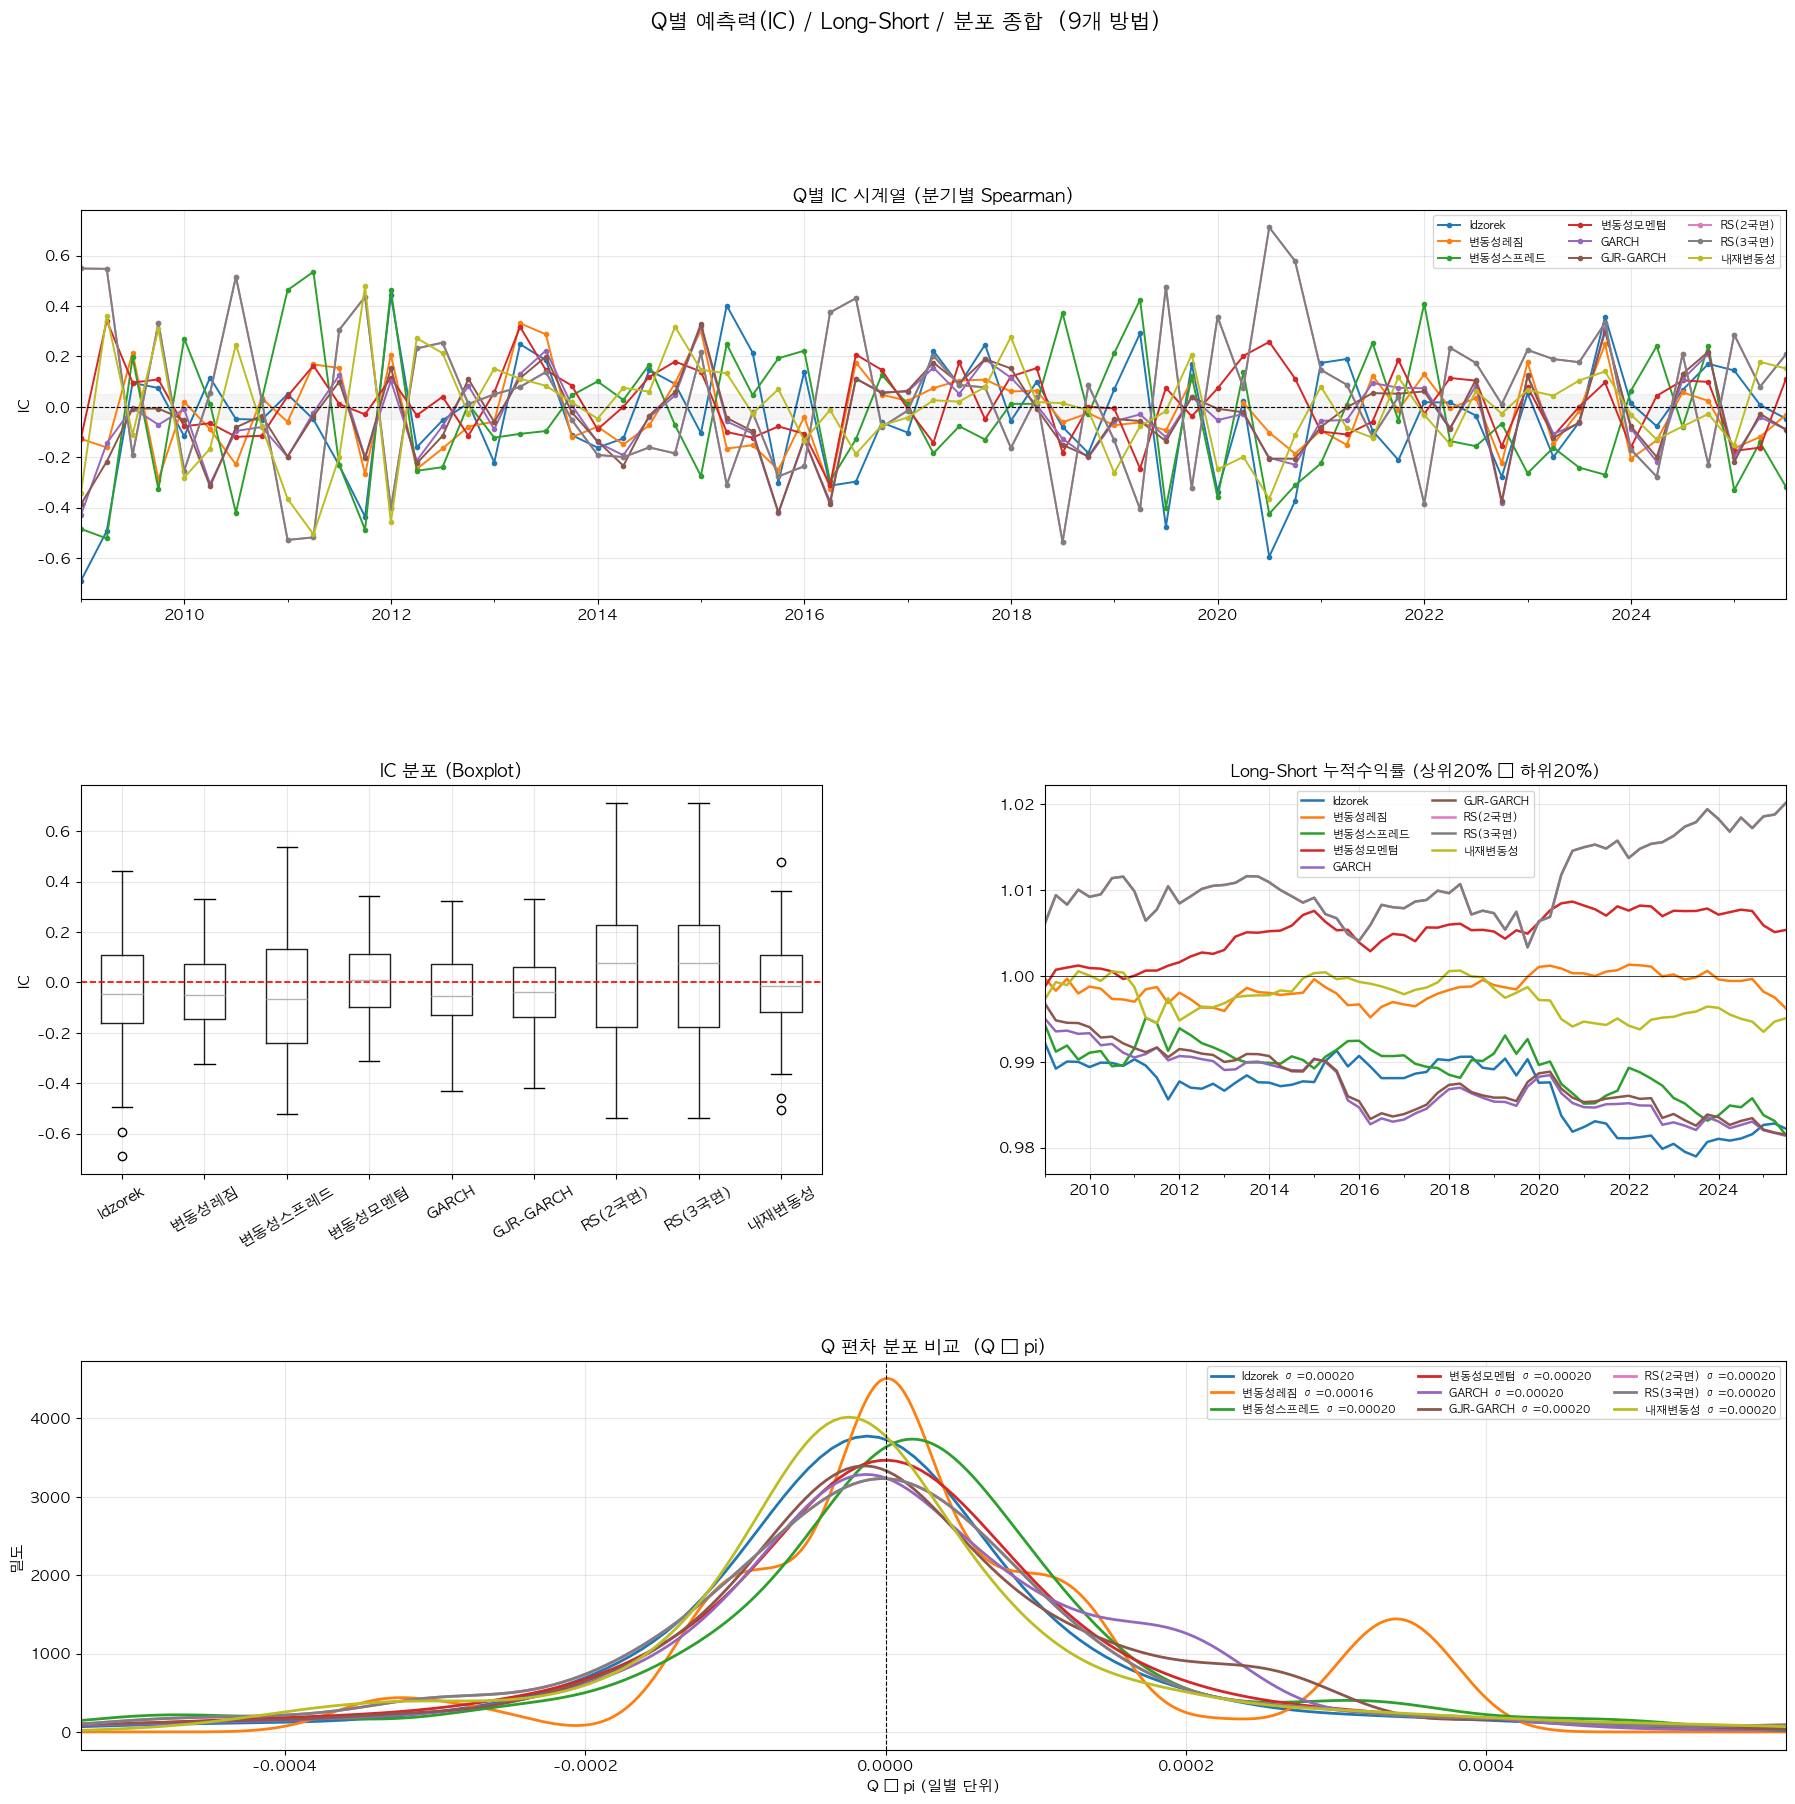

In [219]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 분석 B: Q별 IC / Long-Short / 분포 비교  (전체 9개 방법)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from scipy.stats import spearmanr

# ── 경량 Q 신호 함수 ──────────────────────────────────────────────────────────
# 각 함수: (sl, pi, mkt) → np.ndarray(n_stocks,)   / +값 = 상향뷰

def _sig_idzorek(sl, pi, mkt=None):
    """Idzorek: 12개월 모멘텀 z-score"""
    m12 = (1 + sl.iloc[-min(252, len(sl)):]).prod() - 1
    s   = (m12 - m12.mean()) / (m12.std() + 1e-8)
    return s.values

def _sig_regime(sl, pi, mkt=None):
    """VolRegime: 저변동=+1, 중립=0, 고변동=-1"""
    rv  = sl.rolling(21).std() * np.sqrt(252)
    out = np.zeros(sl.shape[1])
    for i, col in enumerate(sl.columns):
        h = rv[col].dropna()
        if len(h) < 10: continue
        cur = h.iloc[-1]
        if   cur <= h.quantile(0.33): out[i] = +1.0
        elif cur >= h.quantile(0.67): out[i] = -1.0
    return out

def _sig_spread(sl, pi, mkt=None):
    """VolSpread: 종목RV - 시장RV → 높을수록 하향뷰"""
    rv_s = (sl.std() * np.sqrt(252)).values
    rv_m = mkt.std() * np.sqrt(252) if mkt is not None else rv_s.mean()
    sp   = rv_s - rv_m
    return -(sp - sp.mean()) / (sp.std() + 1e-8)

def _sig_vomom(sl, pi, mkt=None):
    """VolMomentum: RV단기/RV장기 - 1 → 증가 추세=하향뷰"""
    if len(sl) < 70: return np.zeros(sl.shape[1])
    rv_s = (sl.iloc[-21:].std() * np.sqrt(252)).values
    rv_l = (sl.iloc[-63:].std() * np.sqrt(252)).values
    vm   = rv_s / (rv_l + 1e-8) - 1
    return -(vm - vm.mean()) / (vm.std() + 1e-8)

def _sig_garch(sl, pi, mkt=None):
    """GARCH(1,1): EWMA 근사 hist_vol/ewma_vol 비율"""
    hist_v = (sl.std() * np.sqrt(252)).values
    ewma_v = np.array([
        sl[c].ewm(span=21).std().iloc[-1] * np.sqrt(252)
        for c in sl.columns
    ])
    ratio = np.clip(hist_v / (ewma_v + 1e-8), 0.5, 2.0)
    sig   = ratio - 1   # +: GARCH 예측 하향 → 역사적 대비 안정 → 상향뷰
    return (sig - sig.mean()) / (sig.std() + 1e-8)

def _sig_gjr(sl, pi, mkt=None):
    """GJR-GARCH: 비대칭 EWMA (하락충격 γ=0.5 추가 가중)"""
    hist_v = (sl.std() * np.sqrt(252)).values
    gjr_v  = np.zeros(sl.shape[1])
    for i, c in enumerate(sl.columns):
        r       = sl[c]
        sym_var = r.ewm(span=21).var().iloc[-1]
        neg_var = (r.clip(upper=0) ** 2).ewm(span=21).mean().iloc[-1]
        gjr_v[i] = np.sqrt(max((sym_var + 0.5 * neg_var) * 252, 1e-8))
    ratio = np.clip(hist_v / (gjr_v + 1e-8), 0.5, 2.0)
    sig   = ratio - 1
    return (sig - sig.mean()) / (sig.std() + 1e-8)

def _sig_rs(sl, pi, mkt, n_states):
    """HMM 국면전환: 국면 가중 π 스케일 (Q ∝ pi × 국면배율)"""
    if mkt is None or len(mkt) < 100:
        return (pi - pi.mean()) / (pi.std() + 1e-8)
    _rv  = mkt.rolling(21).std()  * np.sqrt(252)
    _mom = mkt.rolling(63).mean() * 252
    feat = pd.DataFrame({'ret': mkt, 'vol': _rv, 'mom': _mom}).dropna()
    if len(feat) < 80:
        return (pi - pi.mean()) / (pi.std() + 1e-8)
    X = StandardScaler().fit_transform(feat.values)
    try:
        m = hmm.GaussianHMM(n_components=n_states, covariance_type='full',
                            n_iter=100, random_state=RANDOM_SEED)
        m.fit(X)
        probs  = m.predict_proba(X)
        states = m.predict(X)
        pm = pi.mean()
        Q  = np.zeros(len(pi))
        for s in range(n_states):
            s_mean  = feat['ret'][states == s].mean() * 252
            s_scale = np.clip(1 + (s_mean - pm) / (abs(pm) + 1e-8) * 0.1, 0.7, 1.3)
            Q      += probs[-1, s] * pi * s_scale
    except Exception:
        Q = pi.copy()
    sig = Q - Q.mean()
    return sig / (sig.std() + 1e-8)

def _sig_rs2(sl, pi, mkt=None):
    return _sig_rs(sl, pi, mkt, n_states=2)

def _sig_rs3(sl, pi, mkt=None):
    return _sig_rs(sl, pi, mkt, n_states=3)

def _sig_iv(sl, pi, mkt=None):
    """ImpliedVol: VRP = β×VIX - RV → 높을수록 하향뷰"""
    try:
        vix_now = float(vix.reindex(sl.index).dropna().iloc[-1]) / 100
    except Exception:
        vix_now = 0.20
    rv_s = (sl.std() * np.sqrt(252)).values
    vrp  = np.zeros(sl.shape[1])
    if mkt is not None:
        mkt_al = mkt.reindex(sl.index).dropna()
        for i, c in enumerate(sl.columns):
            common = sl[c].index.intersection(mkt_al.index)
            if len(common) < 60:
                vrp[i] = 0; continue
            y    = sl[c][common].values
            x    = mkt_al[common].values
            beta = np.clip(np.cov(y, x)[0, 1] / (np.var(x) + 1e-8), 0.1, 3.0)
            vrp[i] = abs(beta) * vix_now - rv_s[i]
    else:
        vrp = vix_now - rv_s
    return -(vrp - vrp.mean()) / (vrp.std() + 1e-8)


Q_METHODS = {
    'Idzorek':     _sig_idzorek,
    '변동성레짐':    _sig_regime,
    '변동성스프레드': _sig_spread,
    '변동성모멘텀':   _sig_vomom,
    'GARCH':       _sig_garch,
    'GJR-GARCH':   _sig_gjr,
    'RS(2국면)':    _sig_rs2,
    'RS(3국면)':    _sig_rs3,
    '내재변동성':    _sig_iv,
}

# ── 분기별 루프 ───────────────────────────────────────────────────────────────
sample_dates = [d for d in returns.resample('QE').last().index
                if d >= pd.Timestamp('2006-01-01')]

ic_rec   = {m: [] for m in Q_METHODS}
ls_rec   = {m: [] for m in Q_METHODS}
qdev_rec = {m: [] for m in Q_METHODS}

for i, date in enumerate(sample_dates[:-1]):
    nxt     = sample_dates[i + 1]
    end_idx = returns.index.searchsorted(date, side='right') - 1
    tickers = get_members_capped(date, returns, sp500_membership)
    if len(tickers) < 15: continue

    sl = returns.iloc[end_idx-ROLL_WINDOW:end_idx][tickers]
    sl = sl.dropna(axis=1, thresh=ROLL_WINDOW//2).fillna(0)
    if sl.shape[1] < 15: continue

    sigma  = np.cov(sl.values.T)
    pi     = DELTA * sigma @ (np.ones(sl.shape[1]) / sl.shape[1])
    mkt_sl = mkt_returns.iloc[end_idx-ROLL_WINDOW:end_idx]

    fwd_mask = (returns.index > date) & (returns.index <= nxt)
    fwd_ret  = returns[fwd_mask][sl.columns].mean()

    pi_std = pi.std() + 1e-9

    for mname, fn in Q_METHODS.items():
        sig   = fn(sl, pi, mkt_sl)
        valid = [j for j, t in enumerate(sl.columns)
                 if t in fwd_ret.index and not pd.isna(fwd_ret[t])]
        if len(valid) < 10: continue

        s_v   = sig[valid]
        f_v   = fwd_ret.iloc[valid].values
        ic, _ = spearmanr(s_v, f_v)
        ic_rec[mname].append((date, ic))

        k     = max(int(len(valid) * 0.2), 1)
        order = np.argsort(s_v)
        ls_rec[mname].append((date,
            f_v[order[-k:]].mean() - f_v[order[:k]].mean()))

        qdev_rec[mname].extend((sig * pi_std).tolist())

print(f'\u2705 IC/LS \uacc4\uc0b0 \uc644\ub8cc (9\uac1c \ubc29\ubc95)')

# ── IC 통계표 ─────────────────────────────────────────────────────────────────
print('\n\U0001f4ca Q\ubcc4 IC \ubd84\uc11d')
print('='*72)
print(f'{"\ubc29\ubc95":15s} {"\ud3c9\uade0IC":>8} {"IC std":>8} {"IC_IR":>7} {"\ud788\ud2b8\uc728%":>8} {"t-stat":>8}')
print('-'*72)
ic_summary = {}
for mname, recs in ic_rec.items():
    if not recs: continue
    arr = np.array([r[1] for r in recs])
    mn, sd = arr.mean(), arr.std()
    ir  = mn / (sd + 1e-8)
    hit = (arr > 0).mean() * 100
    t   = mn / (sd / np.sqrt(len(arr)) + 1e-8)
    ic_summary[mname] = dict(mean=mn, std=sd, ir=ir, hit=hit, t=t)
    print(f'{mname:15s} {mn:>8.4f} {sd:>8.4f} {ir:>7.3f} {hit:>8.1f} {t:>8.2f}')
print('='*72)
print('  IC_IR>0.5 \uc548\uc815\uc801, |t|>2 \ud1b5\uacc4\uc801 \uc720\uc758')

# ── 시각화 ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 20))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.3)
pal = sns.color_palette('tab10', len(Q_METHODS))

# ① IC 시계열
ax1 = fig.add_subplot(gs[0, :])
for (mname, recs), c in zip(ic_rec.items(), pal):
    if not recs: continue
    s = pd.Series([r[1] for r in recs], index=[r[0] for r in recs])
    s.plot(ax=ax1, label=mname, color=c, linewidth=1.4, marker='o', markersize=3)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.fill_between(ax1.get_xlim(), -0.05, 0.05, alpha=0.08, color='gray')
ax1.set_title('Q\ubcc4 IC \uc2dc\uacc4\uc5f4 (\ubd84\uae30\ubcc4 Spearman)', fontsize=13, fontweight='bold')
ax1.set_ylabel('IC')
ax1.legend(fontsize=8, ncol=3)

# ② IC 박스플롯
ax2 = fig.add_subplot(gs[1, 0])
ic_df = pd.DataFrame({m: [r[1] for r in recs]
                       for m, recs in ic_rec.items() if recs})
ic_df.boxplot(ax=ax2)
ax2.axhline(0, color='red', linestyle='--', linewidth=1.2)
ax2.set_title('IC \ubd84\ud3ec (Boxplot)', fontsize=13, fontweight='bold')
ax2.set_ylabel('IC')
ax2.tick_params(axis='x', rotation=30)

# ③ Long-Short 누적수익률
ax3 = fig.add_subplot(gs[1, 1])
for (mname, recs), c in zip(ls_rec.items(), pal):
    if not recs: continue
    s = pd.Series([r[1] for r in recs], index=[r[0] for r in recs])
    (1 + s).cumprod().plot(ax=ax3, label=mname, color=c, linewidth=1.8)
ax3.axhline(1, color='black', linewidth=0.5)
ax3.set_title('Long-Short \ub204\uc801\uc218\uc775\ub960 (\uc0c1\uc70420% \u2212 \ud558\uc70420%)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=8, ncol=2)

# ④ Q 편차 KDE
ax4 = fig.add_subplot(gs[2, :])
for (mname, vals), c in zip(qdev_rec.items(), pal):
    s = pd.Series(vals).dropna()
    if len(s) == 0: continue
    s.plot.kde(ax=ax4, label=f'{mname}  \u03c3={s.std():.5f}', color=c,
               linewidth=2, bw_method=0.2)
ax4.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax4.set_title('Q \ud3b8\ucc28 \ubd84\ud3ec \ube44\uad50  (Q \u2212 pi)', fontsize=13, fontweight='bold')
ax4.set_xlabel('Q \u2212 pi (\uc77c\ubcc4 \ub2e8\uc704)')
ax4.set_ylabel('\ubc00\ub3c4')
ax4.legend(fontsize=8, ncol=3)
all_vals = np.concatenate([v for v in qdev_rec.values() if v])
if len(all_vals) > 0:
    xlim = np.percentile(all_vals, [1, 99])
    ax4.set_xlim(xlim)

plt.suptitle('Q\ubcc4 \uc608\uce21\ub825(IC) / Long-Short / \ubd84\ud3ec \uc885\ud569  (9\uac1c \ubc29\ubc95)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('q_ic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


✅ Q 수집 완료

📊 Q 분포 통계 (연간환산 %/yr)
방법                    평균      중앙값      std    95%CI하단    95%CI상단
--------------------------------------------------------------------------------
Idzorek            11.66     9.48     8.52    11.4588    11.8641
변동성스프레드            11.66     9.94     6.99    11.4954    11.8275
변동성모멘텀             11.66     9.34     8.37    11.4626    11.8604
GARCH              17.21    12.02    15.62    16.8343    17.5770
GJR-GARCH          16.00    10.83    15.18    15.6427    16.3645
RS(2국면)            13.94    11.26     9.76    13.7038    14.1676
RS(3국면)            13.69    11.22     9.70    13.4568    13.9179
pi(기준)             11.66     9.41     8.03    11.4705    11.8524


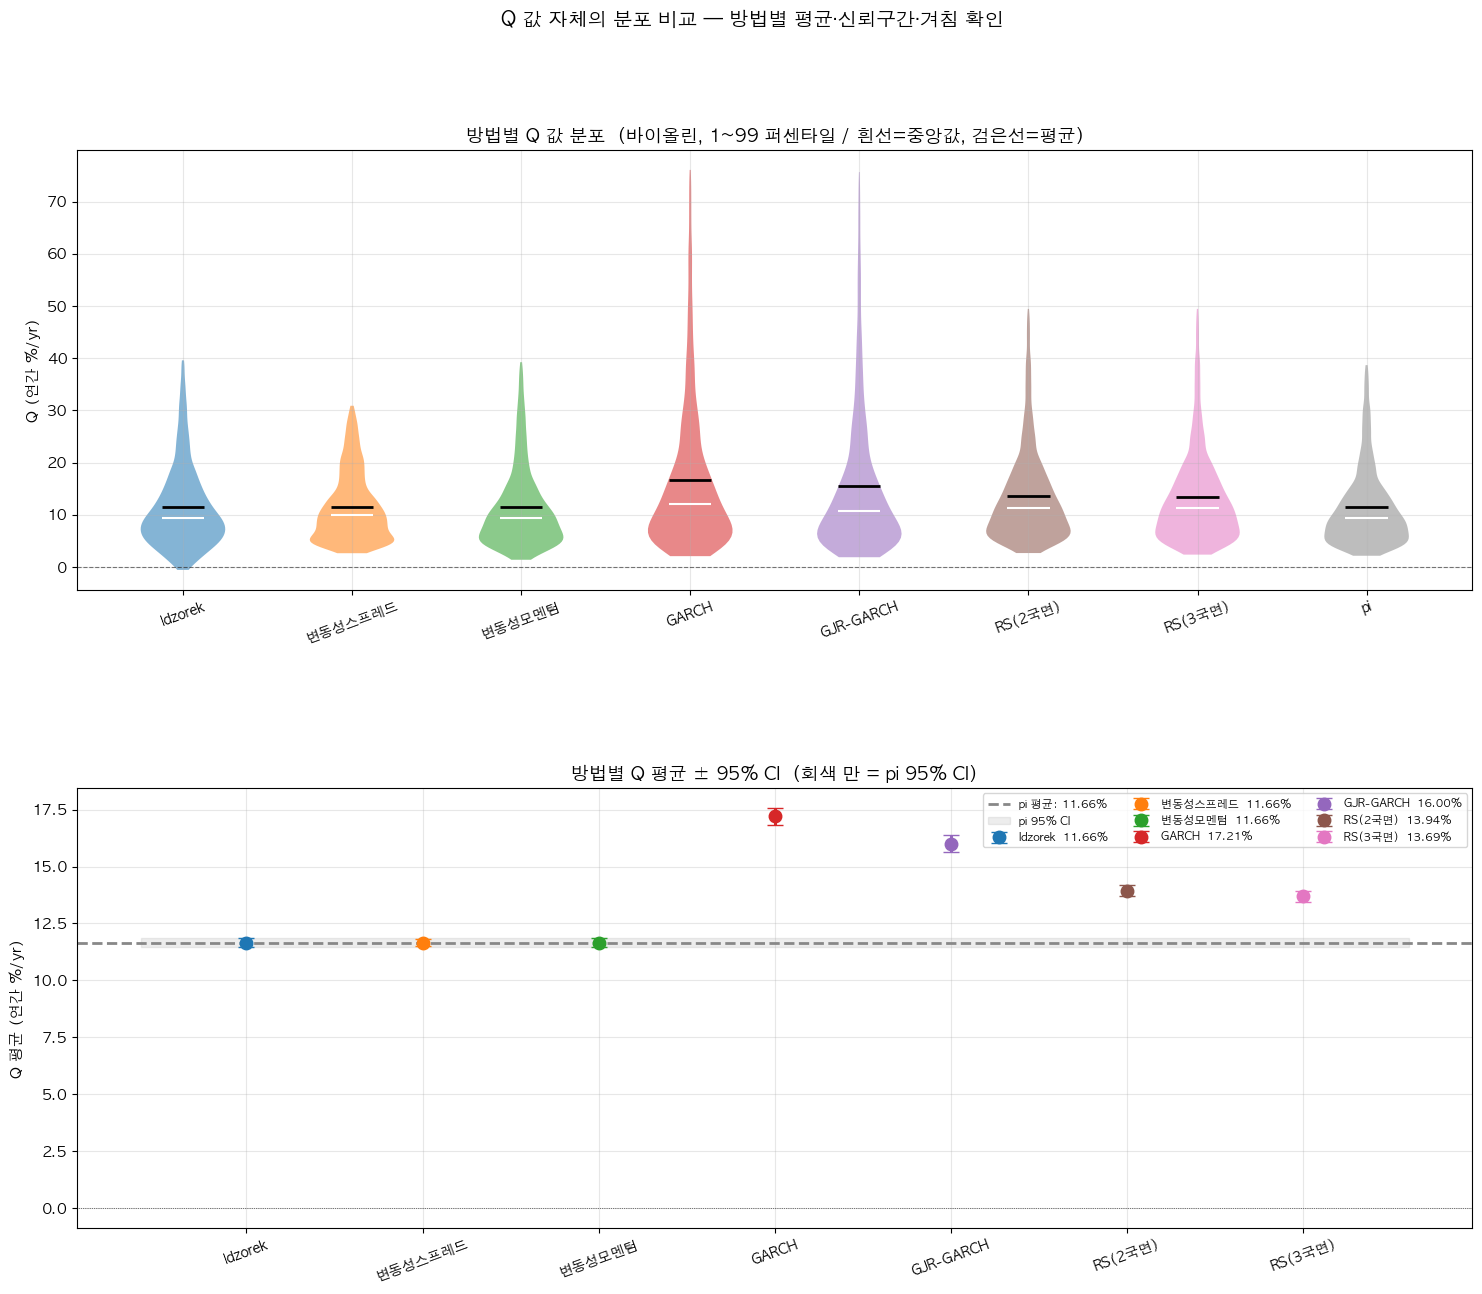

In [220]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 분석 C: Q 값 자체의 분포 비교 — 방법별 평균 · 신뢰구간 · 겹침 확인
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── 각 방법의 실제 Q 계산 함수 ────────────────────────────────────────────────
# fit_predict 와 동일한 공식, 반환값: Q np.ndarray (일별 단위)

def _q_idzorek(sl, pi, mkt=None):
    mom_12 = (1 + sl.iloc[-min(252, len(sl)):]).prod() - 1
    sig    = (mom_12 - mom_12.mean()) / (mom_12.std() + 1e-8)
    return pi + 0.03/252 * sig.values

def _q_regime(sl, pi, mkt=None):
    rv = sl.rolling(21).std() * np.sqrt(252)
    Q  = pi.copy()
    for i, col in enumerate(sl.columns):
        h = rv[col].dropna()
        if len(h) < 10: continue
        cur   = h.iloc[-1]
        alpha = 0.02 * h.mean()
        if   cur <= h.quantile(0.33): Q[i] = pi[i] + alpha
        elif cur >= h.quantile(0.67): Q[i] = pi[i] - alpha
    return Q

def _q_spread(sl, pi, mkt=None):
    rv_s = (sl.std() * np.sqrt(252)).values
    rv_m = mkt.std() * np.sqrt(252) if mkt is not None else rv_s.mean()
    sp   = rv_s - rv_m
    sp_n = (sp - sp.mean()) / (sp.std() + 1e-8)
    return pi - 0.5 * sp_n * pi.std()

def _q_vomom(sl, pi, mkt=None):
    if len(sl) < 70: return pi.copy()
    rv_s = (sl.iloc[-21:].std() * np.sqrt(252)).values
    rv_l = (sl.iloc[-63:].std() * np.sqrt(252)).values
    vm   = rv_s / (rv_l + 1e-8) - 1
    vm_n = (vm - vm.mean()) / (vm.std() + 1e-8)
    return pi - 0.5 * vm_n * pi.std()

def _q_garch(sl, pi, mkt=None):
    hist_v = (sl.std() * np.sqrt(252)).values
    ewma_v = np.array([sl[c].ewm(span=21).std().iloc[-1] * np.sqrt(252)
                       for c in sl.columns])
    return pi * np.clip(hist_v / (ewma_v + 1e-8), 0.5, 2.0)

def _q_gjr(sl, pi, mkt=None):
    hist_v = (sl.std() * np.sqrt(252)).values
    gjr_v  = np.zeros(sl.shape[1])
    for i, c in enumerate(sl.columns):
        r        = sl[c]
        sym_var  = r.ewm(span=21).var().iloc[-1]
        neg_var  = (r.clip(upper=0) ** 2).ewm(span=21).mean().iloc[-1]
        gjr_v[i] = np.sqrt(max((sym_var + 0.5 * neg_var) * 252, 1e-8))
    return pi * np.clip(hist_v / (gjr_v + 1e-8), 0.5, 2.0)

def _q_rs_impl(sl, pi, mkt, n_states):
    if mkt is None or len(mkt) < 100: return pi.copy()
    _rv  = mkt.rolling(21).std()  * np.sqrt(252)
    _mom = mkt.rolling(63).mean() * 252
    feat = pd.DataFrame({'ret': mkt, 'vol': _rv, 'mom': _mom}).dropna()
    if len(feat) < 80: return pi.copy()
    X = StandardScaler().fit_transform(feat.values)
    try:
        m = hmm.GaussianHMM(n_components=n_states, covariance_type='full',
                            n_iter=100, random_state=RANDOM_SEED)
        m.fit(X)
        probs  = m.predict_proba(X)
        states = m.predict(X)
        pm = pi.mean()
        Q  = np.zeros(len(pi))
        for s in range(n_states):
            s_mean  = feat['ret'][states == s].mean() * 252
            s_scale = np.clip(1 + (s_mean - pm) / (abs(pm) + 1e-8) * 0.1, 0.7, 1.3)
            Q      += probs[-1, s] * pi * s_scale
        return Q
    except Exception:
        return pi.copy()

def _q_rs2(sl, pi, mkt=None): return _q_rs_impl(sl, pi, mkt, 2)
def _q_rs3(sl, pi, mkt=None): return _q_rs_impl(sl, pi, mkt, 3)

def _q_iv(sl, pi, mkt=None):
    try:
        vix_now = float(vix.reindex(sl.index).dropna().iloc[-1]) / 100
    except Exception:
        vix_now = 0.20
    rv_s = (sl.std() * np.sqrt(252)).values
    vrp  = np.zeros(sl.shape[1])
    if mkt is not None:
        mkt_al = mkt.reindex(sl.index).dropna()
        for i, c in enumerate(sl.columns):
            common = sl[c].index.intersection(mkt_al.index)
            if len(common) < 60: continue
            y    = sl[c][common].values
            x    = mkt_al[common].values
            beta = np.clip(np.cov(y, x)[0, 1] / (np.var(x) + 1e-8), 0.1, 3.0)
            vrp[i] = abs(beta) * vix_now - rv_s[i]
    else:
        vrp = vix_now - rv_s
    return pi - 0.5 * vrp

Q_FUNCS = {
    'Idzorek':     _q_idzorek,
#    '변동성레짐':    _q_regime,
    '변동성스프레드': _q_spread,
    '변동성모멘텀':   _q_vomom,
    'GARCH':       _q_garch,
    'GJR-GARCH':   _q_gjr,
    'RS(2국면)':    _q_rs2,
    'RS(3국면)':    _q_rs3,
#    '내재변동성':    _q_iv,
}

# ── 분기별 Q 수집 ─────────────────────────────────────────────────────────────
sample_dates = [d for d in returns.resample('QE').last().index
                if d >= pd.Timestamp('2006-01-01')]

q_pool  = {m: [] for m in Q_FUNCS}
pi_pool = []

for date in sample_dates:
    end_idx = returns.index.searchsorted(date, side='right') - 1
    tickers = get_members_capped(date, returns, sp500_membership)
    if len(tickers) < 15: continue

    sl = returns.iloc[end_idx-ROLL_WINDOW:end_idx][tickers]
    sl = sl.dropna(axis=1, thresh=ROLL_WINDOW//2).fillna(0)
    if sl.shape[1] < 15: continue

    sigma  = np.cov(sl.values.T)
    pi     = DELTA * sigma @ (np.ones(sl.shape[1]) / sl.shape[1])
    mkt_sl = mkt_returns.iloc[end_idx-ROLL_WINDOW:end_idx]

    pi_pool.extend((pi * 252 * 100).tolist())

    for mname, fn in Q_FUNCS.items():
        try:
            Q = fn(sl, pi, mkt_sl)
            q_pool[mname].extend((Q * 252 * 100).tolist())
        except Exception:
            pass

print('\u2705 Q \uc218\uc9d1 \uc644\ub8cc')

# ── 통계 요약 ─────────────────────────────────────────────────────────────────
print('\n\U0001f4ca Q \ubd84\ud3ec \ud1b5\uacc4 (\uc5f0\uac04\ud658\uc0b0 %/yr)')
print('='*80)
print(f'{"\ubc29\ubc95":15s} {"\ud3c9\uade0":>8} {"\uc911\uc559\uac12":>8} {"std":>8} {"95%CI\ud558\ub2e8":>10} {"95%CI\uc0c1\ub2e8":>10}')
print('-'*80)

q_stats = {}
pi_arr  = np.array(pi_pool)
pi_se   = pi_arr.std() / np.sqrt(len(pi_arr))

for mname, vals in q_pool.items():
    arr  = np.array(vals)
    n    = len(arr)
    mn   = arr.mean()
    med  = np.median(arr)
    sd   = arr.std()
    se   = sd / np.sqrt(n)
    lo, hi = mn - 1.96*se, mn + 1.96*se
    q_stats[mname] = dict(mean=mn, median=med, std=sd, ci_lo=lo, ci_hi=hi)
    print(f'{mname:15s} {mn:>8.2f} {med:>8.2f} {sd:>8.2f} {lo:>10.4f} {hi:>10.4f}')

_pi_lbl = 'pi(기준)'
print(f'{_pi_lbl:15s} {pi_arr.mean():>8.2f} {np.median(pi_arr):>8.2f} '
      f'{pi_arr.std():>8.2f} {pi_arr.mean()-1.96*pi_se:>10.4f} {pi_arr.mean()+1.96*pi_se:>10.4f}')
print('='*80)

# ── 시각화 ────────────────────────────────────────────────────────────────────
methods_order = list(Q_FUNCS.keys()) + ['pi']
pal       = sns.color_palette('tab10', len(Q_FUNCS))
pi_color  = '#888888'

fig, axes = plt.subplots(2, 1, figsize=(18, 14), gridspec_kw={'hspace': 0.45})

# ① 바이올린 플롯 — 전체 분포 (1~99 퍼센타일 클리핑)
ax1 = axes[0]
plot_data = []
for m in methods_order:
    arr = np.array(q_pool[m] if m != 'pi' else pi_pool)
    lo, hi = np.percentile(arr, 1), np.percentile(arr, 99)
    plot_data.append(arr[(arr >= lo) & (arr <= hi)])

vp = ax1.violinplot(plot_data,
                    positions=range(len(methods_order)),
                    showmeans=True, showmedians=True, showextrema=False)

colors = pal + [pi_color]
for pc, col in zip(vp['bodies'], colors):
    pc.set_facecolor(col); pc.set_alpha(0.55)
vp['cmeans'].set_color('black');   vp['cmeans'].set_linewidth(2)
vp['cmedians'].set_color('white'); vp['cmedians'].set_linewidth(1.5)

ax1.set_xticks(range(len(methods_order)))
ax1.set_xticklabels(methods_order, rotation=20, fontsize=10)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.set_ylabel('Q (\uc5f0\uac04 %/yr)')
ax1.set_title('\ubc29\ubc95\ubcc4 Q \uac12 \ubd84\ud3ec  (\ubc14\uc774\uc62c\ub9b0, 1~99 \ud37c\uc13c\ud0c0\uc77c / \ud770\uc120=\uc911\uc559\uac12, \uac80\uc740\uc120=\ud3c9\uade0)',
              fontweight='bold')

# ② 평균 ± 95% CI (오차막대) — pi 참조 포함
ax2 = axes[1]
x = np.arange(len(Q_FUNCS))

for i, (mname, c) in enumerate(zip(Q_FUNCS.keys(), pal)):
    st = q_stats[mname]
    ax2.errorbar(i, st['mean'],
                 yerr=[[st['mean'] - st['ci_lo']], [st['ci_hi'] - st['mean']]],
                 fmt='o', color=c, markersize=9, linewidth=2.2, capsize=6,
                 label=f"{mname}  {st['mean']:.2f}%")

# pi 참조 띠
ax2.axhline(pi_arr.mean(), color=pi_color, linewidth=2, linestyle='--',
            label=f'pi \ud3c9\uade0: {pi_arr.mean():.2f}%')
ax2.fill_between([-0.6, len(Q_FUNCS)-0.4],
                 pi_arr.mean() - 1.96*pi_se,
                 pi_arr.mean() + 1.96*pi_se,
                 alpha=0.15, color=pi_color, label='pi 95% CI')

ax2.set_xticks(x)
ax2.set_xticklabels(list(Q_FUNCS.keys()), rotation=20, fontsize=10)
ax2.set_ylabel('Q \ud3c9\uade0 (\uc5f0\uac04 %/yr)')
ax2.set_title('\ubc29\ubc95\ubcc4 Q \ud3c9\uade0 \u00b1 95% CI  (\ud68c\uc0c9 \ub9cc = pi 95% CI)',
              fontweight='bold')
ax2.legend(fontsize=8, ncol=3, loc='best')
ax2.axhline(0, color='black', linewidth=0.5, linestyle=':')

plt.suptitle('Q \uac12 \uc790\uccb4\uc758 \ubd84\ud3ec \ube44\uad50 \u2014 \ubc29\ubc95\ubcc4 \ud3c9\uade0\u00b7\uc2e0\ub8b0\uad6c\uac04\u00b7\uaca8\uce68 \ud655\uc778',
             fontsize=14, fontweight='bold')
plt.savefig('q_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
